In [32]:
import numpy
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt

import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')

import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



In [33]:

def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    base_path = f"{base_path_root}/neqs{NEQS}"
    pattern = os.path.join(base_path, f"{param_name}_*")
    dirs = glob.glob(pattern)

    values = []

    for d in dirs:
        try:
            base = os.path.basename(d)
            val_str = base.replace(f"{param_name}_", "")
            val = float(val_str)
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    values.sort(key=lambda x: x[0])

    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        if len(values) > 0:
            print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        else:
            print("Parameter range: none found")
        print(f"{'='*60}\n")

    return values

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from matplotlib.gridspec import GridSpec

SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}


def plot_big_normalized_scan_summary(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    ref_floor_spec=1e-30,
    ref_floor_bg=1e-20,
    frac_floor=1e-100,
    H_scale=1.0,
    V_scale=1.0,
    cmap_name="plasma",
    save_name=None,
    suptitle=None,
    show=True,
):
    """
    Build one large figure containing:

      Row 1: normalized P_s(k), normalized P_t(k)
      Row 2: fractional error in normalized P_s(k), fractional error in normalized P_t(k)
      Row 3: normalized H(N), fractional error in normalized H(N)
      Row 4: normalized V(phi), fractional error in normalized V(phi)
      Row 5: summary stats table for Pt and H

    Definitions
    -----------
    Spectra are shape-normalized:
        P_s_norm(k) = P_s(k) / P_s(k_ref)
        P_t_norm(k) = P_t(k) / P_t(k_ref)

    Background curves are normalized at N_ref:
        H_norm(N)   = H(N) / H(N_ref)
        V_norm(phi) = V(phi) / V(N_ref)

    Error curves are fractional differences relative to the chosen base model:
        (curve - curve_base) / curve_base
    """

    def get_scan_info(neqs):
        if neqs not in SCAN_INFO:
            raise ValueError(f"Unsupported NEQS = {neqs}")
        return SCAN_INFO[neqs]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float
        )

    def prepare_increasing(x, y):
        """
        Accept monotonic x only.
        If fully decreasing, reverse x and y together.
        Refuse non-monotonic arrays.
        """
        x = np.asarray(x)
        y = np.asarray(y)

        if x.shape != y.shape:
            raise ValueError("x and y must have the same shape")

        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            raise ValueError(
                "x is not monotonic; refusing to reorder because that could distort physics."
            )

    def normalize_curve_at_ref(x, y, x_ref, ref_floor):
        x_use, y_use = prepare_increasing(x, y)

        if x_ref < np.min(x_use) or x_ref > np.max(x_use):
            raise ValueError(
                f"Reference x_ref={x_ref} outside range [{np.min(x_use)}, {np.max(x_use)}]"
            )

        y_ref = np.interp(x_ref, x_use, y_use)

        if np.abs(y_ref) < ref_floor:
            raise ValueError(
                f"Reference value too small for normalization at x_ref={x_ref}: {y_ref:.3e}"
            )

        return x_use, y_use / y_ref, y_ref

    def fractional_difference_on_common_x(x_base, y_base, x_cmp, y_cmp, floor=1e-100):
        """
        Evaluate:
            (y_cmp_interp - y_base) / y_base
        on the overlap, using the base grid.
        """
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp))
        xmax = min(np.max(x_base), np.max(x_cmp))

        mask = (x_base >= xmin) & (x_base <= xmax)
        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        denom = np.where(np.abs(y_base_use) > floor, y_base_use, np.nan)
        frac = (y_cmp_interp - y_base_use) / denom
        return x_use, frac

    def load_specs(value):
        val_str = f"{value:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        file_s = os.path.join(folder, f"spec_s_neqs{NEQS}.dat")
        file_t = os.path.join(folder, f"spec_t_neqs{NEQS}.dat")

        data_s = np.loadtxt(file_s)
        data_t = np.loadtxt(file_t)

        k_s = data_s[:, 0]
        Ps = np.abs(data_s[:, 1])

        k_t = data_t[:, 0]
        Pt = np.abs(data_t[:, 1])

        return k_s, Ps, k_t, Pt

    def load_path(value):
        val_str = f"{value:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        file_path = os.path.join(
            folder,
            f"path_neqs{NEQS}_{scan_name}_{val_str}.dat"
        )

        return pd.read_csv(file_path, sep=r"\s+", header=None).values



    def extract_cols(path_data):
        """
        Assumed column convention:
            phi = 0
            H   = 1
            N   = NEQS
            V   = NEQS + 1
        """
        phi = path_data[:, 0]
        H = path_data[:, 1]
        N = path_data[:, NEQS]
        V = path_data[:, NEQS + 1]
        return phi, H, N, V

    def get_normalized_H_vs_N(path_data):
        _, H, N, _ = extract_cols(path_data)
        N_use, H_norm, H_ref = normalize_curve_at_ref(N, H, N_ref, ref_floor_bg)
        return N_use, H_norm, H_ref

#     def get_normalized_V_vs_phi(path_data):
#         phi_raw, _, N_raw, V_raw = extract_cols(path_data)

#         # First use monotonic N ordering for physical trajectory order
#         N_use, phi_use = prepare_increasing(N_raw, phi_raw)
#         _, V_use = prepare_increasing(N_raw, V_raw)

#         if N_ref < np.min(N_use) or N_ref > np.max(N_use):
#             raise ValueError(
#                 f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
#             )

#         V_ref = np.interp(N_ref, N_use, V_use)

#         if np.abs(V_ref) < ref_floor_bg:
#             raise ValueError(
#                 f"Reference V(N_ref) too small at N_ref={N_ref}: {V_ref:.3e}"
#             )

#         V_norm = V_use / V_ref

    def get_normalized_V_vs_phi(path_data):
        phi_raw, _, N_raw, V_raw = extract_cols(path_data)

        N_use, phi_use = prepare_increasing(N_raw, phi_raw)
        _, V_use = prepare_increasing(N_raw, V_raw)


        if N_ref < np.min(N_use) or N_ref > np.max(N_use):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        V_ref = np.interp(N_ref, N_use, V_use)

        if np.abs(V_ref) < ref_floor_bg:
            raise ValueError(
                f"Reference V(N_ref) too small at N_ref={N_ref}: {V_ref:.3e}"
            )
        V_norm = V_use / V_ref

#         phi_plot, V_plot = prepare_increasing(phi_use, V_norm)
#         return phi_plot, V_plot, V_ref



        # Then prepare phi-space version
#         phi_plot, V_plot = prepare_increasing(phi_use, V_norm)
        
        phi_plot = phi_use
        V_plot = V_norm
        return phi_plot, V_plot, V_ref
   

    def setup_colorbar(fig, axes, lam_vals, scan_symbol, cmap_name="plasma"):
#         cmap = cm.get_cmap(cmap_name)
        import matplotlib as mpl
        cmap = mpl.colormaps[cmap_name]
        norm = mcolors.Normalize(vmin=np.min(lam_vals), vmax=np.max(lam_vals))
        sm = cm.ScalarMappable(cmap=cmap, norm=norm)

        cbar = fig.colorbar(
            sm,
            ax=axes,
            orientation="vertical",
            fraction=0.015,
            pad=0.02
        )
        cbar.set_label(rf"${scan_symbol}$", fontsize=12)
        return cmap, norm

    # ---------------- setup ----------------
    scan_name, scan_symbol = get_scan_info(NEQS)
    lamX_numeric = sanitize_lam_values(lamX_values)

    # ---------------- base model ----------------
    try:
        k_s_base, Ps_base, k_t_base, Pt_base = load_specs(baseX)
        path_base = load_path(baseX)
    except FileNotFoundError as e:
        raise FileNotFoundError(
            f"Base model files not found for {scan_name} = {baseX:.5e}"
        ) from e

    k_s_base, Ps_base_norm, _ = normalize_curve_at_ref(
        k_s_base, Ps_base, k_ref, ref_floor_spec
    )
    k_t_base, Pt_base_norm, _ = normalize_curve_at_ref(
        k_t_base, Pt_base, k_ref, ref_floor_spec
    )

    N_H_base, H_base_norm, _ = get_normalized_H_vs_N(path_base)
    phi_V_base, V_base_norm, _ = get_normalized_V_vs_phi(path_base)

    # ---------------- figure ----------------
    fig = plt.figure(figsize=(18, 22), constrained_layout=True)
    gs = GridSpec(
        5, 2,
        figure=fig,
        height_ratios=[1.0, 1.0, 1.0, 1.0, 1.1]
    )

    ax_ps       = fig.add_subplot(gs[0, 0])
    ax_pt       = fig.add_subplot(gs[0, 1])
    ax_ps_err   = fig.add_subplot(gs[1, 0])
    ax_pt_err   = fig.add_subplot(gs[1, 1])
    ax_h        = fig.add_subplot(gs[2, 0])
    ax_h_err    = fig.add_subplot(gs[2, 1])
    ax_vphi     = fig.add_subplot(gs[3, 0])
    ax_vphi_err = fig.add_subplot(gs[3, 1])
    ax_table    = fig.add_subplot(gs[4, :])
    ax_table.axis("off")

    plot_axes = [ax_ps, ax_pt, ax_ps_err, ax_pt_err, ax_h, ax_h_err, ax_vphi, ax_vphi_err]
    cmap, norm = setup_colorbar(fig, plot_axes, lamX_numeric, scan_symbol, cmap_name=cmap_name)

    # ---------------- scan loop ----------------
    stats_rows = []

    for lamX in lamX_numeric:
        try:
            k_s, Ps, k_t, Pt = load_specs(lamX)
            path_data = load_path(lamX)

            # normalize spectra
            k_s_use, Ps_norm, _ = normalize_curve_at_ref(
                k_s, Ps, k_ref, ref_floor_spec
            )
            k_t_use, Pt_norm, _ = normalize_curve_at_ref(
                k_t, Pt, k_ref, ref_floor_spec
            )

            # normalize background
            N_H, H_norm, _ = get_normalized_H_vs_N(path_data)
            phi_V, V_norm, _ = get_normalized_V_vs_phi(path_data)

            color = cmap(norm(lamX))

            # fractional differences relative to base
            k_ps_err, frac_ps = fractional_difference_on_common_x(
                k_s_base, Ps_base_norm, k_s_use, Ps_norm, floor=frac_floor
            )
            k_pt_err, frac_pt = fractional_difference_on_common_x(
                k_t_base, Pt_base_norm, k_t_use, Pt_norm, floor=frac_floor
            )
            N_h_err, frac_h = fractional_difference_on_common_x(
                N_H_base, H_base_norm, N_H, H_norm, floor=frac_floor
            )
            phi_v_err, frac_v = fractional_difference_on_common_x(
                phi_V_base, V_base_norm, phi_V, V_norm, floor=frac_floor
            )

            # top/background plots
#             ax_ps.plot(k_s_use, Ps_norm, color=color, lw=1.6, alpha=0.9)
            k_max_scalar = 10.0
            mask_k = k_s_use <= k_max_scalar

            ax_ps.plot(
                k_s_use[mask_k],
                Ps_norm[mask_k],
                color=color,
                lw=1.6,
                alpha=0.9
            )
            ax_pt.plot(k_t_use, Pt_norm, color=color, lw=1.6, alpha=0.9)
            ax_h.plot(N_H, H_scale * H_norm, color=color, lw=1.6, alpha=0.9)
            ax_vphi.plot(phi_V, V_scale * V_norm, color=color, lw=1.6, alpha=0.9)

            # error plots
#             ax_ps_err.plot(k_ps_err, frac_ps, color=color, lw=1.6, alpha=0.9)
            mask_k_err = k_ps_err <= k_max_scalar

            ax_ps_err.plot(
                k_ps_err[mask_k_err],
                frac_ps[mask_k_err],
                color=color,
                lw=1.6,
                alpha=0.9
            )
            ax_pt_err.plot(k_pt_err, frac_pt, color=color, lw=1.6, alpha=0.9)
            ax_h_err.plot(N_h_err, frac_h, color=color, lw=1.6, alpha=0.9)
            ax_vphi_err.plot(phi_v_err, frac_v, color=color, lw=1.6, alpha=0.9)

            # summary table values
            mask_ps_stats = k_ps_err <= k_max_scalar
            frac_ps_use = frac_ps[mask_ps_stats]

            stats_rows.append({
                "lamX": lamX,

                # tensor (%)
                "mean_dPt_pct": 100 * np.nanmean(frac_pt),
                "max_dPt_pct": 100 * np.nanmax(np.abs(frac_pt)),

                # scalar (%), restricted k
                "mean_dPs_pct": 100 * np.nanmean(frac_ps_use),
                "max_dPs_pct": 100 * np.nanmax(np.abs(frac_ps_use)),

                # background (%)
                "mean_dH_pct": 100 * np.nanmean(frac_h),
                "max_dH_pct": 100 * np.nanmax(np.abs(frac_h)),

                "mean_dV_pct": 100 * np.nanmean(frac_v),
                "max_dV_pct": 100 * np.nanmax(np.abs(frac_v)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name} = {lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name} = {lamX:.5e}: {e}")

    stats_df = pd.DataFrame(stats_rows)

    # ---------------- titles ----------------
    ax_ps.set_title(
        rf"Normalized scalar spectrum: $\mathcal{{P}}_\mathcal{{R}}(k)/\mathcal{{P}}_\mathcal{{R}}({k_ref})$"
    )
    ax_pt.set_title(
        rf"Normalized tensor spectrum: $\mathcal{{P}}_t(k)/\mathcal{{P}}_t({k_ref})$"
    )

    ax_ps_err.set_title(r"Fractional error in normalized $\mathcal{P}_{\mathcal{R}}(k)$")
    ax_pt_err.set_title(r"Fractional error in normalized $\mathcal{P}_t(k)$")

    ax_h.set_title(rf"Normalized Hubble parameter: $H(N)/H({N_ref})$")
    ax_h_err.set_title(r"Fractional error in normalized $H(N)$")

    ax_vphi.set_title(rf"Normalized potential: $V(\phi)/V(N={N_ref})$")
    ax_vphi_err.set_title(r"Fractional error in normalized $V(\phi)$")

    # ---------------- y labels ----------------
    ax_ps.set_ylabel(r"$\mathcal{P}_{\mathcal{R},\mathrm{norm}}$")
    ax_pt.set_ylabel(r"$\mathcal{P}_{t,\mathrm{norm}}$")

    ax_ps_err.set_ylabel(
        r"$\left(\mathcal{P}_{\mathcal{R},\mathrm{norm}}-\mathcal{P}_{\mathcal{R},\mathrm{base}}\right)/\mathcal{P}_{\mathcal{R},\mathrm{base}}$"
    )
    ax_pt_err.set_ylabel(
        r"$\left(\mathcal{P}_{t,\mathrm{norm}}-\mathcal{P}_{t,\mathrm{base}}\right)/\mathcal{P}_{t,\mathrm{base}}$"
    )

    if H_scale == 1.0:
      
        ax_h.set_ylabel(r"$H/H(N_{\mathrm{ref}})$")
    else:
#         ax_h.set_ylabel(rf"${H_scale:.0e}\,H/H(N_{{\mathrm{{ref}}}})$")
        ax_h.set_ylabel(rf"$10^{6}H/H(N_{{\mathrm{{ref}}}})$")


    ax_h_err.set_ylabel(
        r"$\left(H_{\mathrm{norm}}-H_{\mathrm{base}}\right)/H_{\mathrm{base}}$"
    )

    if V_scale == 1.0:
        ax_vphi.set_ylabel(r"$V/V(N_{\mathrm{ref}})$")
    else:
#         ax_vphi.set_ylabel(rf"${V_scale:.0e}\,V/V(N_{{\mathrm{{ref}}}})$")
        ax_vphi.set_ylabel(rf"$10^{{13}}V/V(N_{{\mathrm{{ref}}}})$")


    ax_vphi_err.set_ylabel(
        r"$\left(V_{\mathrm{norm}}-V_{\mathrm{base}}\right)/V_{\mathrm{base}}$"
    )

    # ---------------- x labels ----------------
    ax_ps_err.set_xlabel(r"$k \,[h\,\mathrm{Mpc}^{-1}]$")
    ax_pt_err.set_xlabel(r"$k \,[h\,\mathrm{Mpc}^{-1}]$")
    ax_h.set_xlabel(r"$N$")
    ax_h_err.set_xlabel(r"$N$")
    ax_vphi.set_xlabel(r"$\phi$")
    ax_vphi_err.set_xlabel(r"$\phi$")

    # ---------------- styling ----------------
    # spectra: log x and log y
    for ax in [ax_ps, ax_pt]:
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()

    # spectra errors: log x only
    for ax in [ax_ps_err, ax_pt_err]:
        ax.set_xscale("log")
        ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
        ax.grid(True, alpha=0.25)
        ax.minorticks_on()

    # H plot: inverted x and log y
    ax_h.invert_xaxis()
#     ax_h.set_yscale("log")
    ax_h.grid(True, alpha=0.25)

    # H error: inverted x, linear y
    ax_h_err.invert_xaxis()
    ax_h_err.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax_h_err.grid(True, alpha=0.25)

    # V(phi) plot: inverted x and log y
#     ax_vphi.invert_xaxis()
#     ax_vphi.set_yscale("log")
    ax_vphi.grid(True, alpha=0.25)

    # V(phi) error: inverted x, linear y
#     ax_vphi_err.invert_xaxis()
    ax_vphi_err.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax_vphi_err.grid(True, alpha=0.25)
# ---------------- simple printed summary ----------------
    ax_table.set_visible(False)

    ax_table.set_visible(False)

    if not stats_df.empty:
        print("\n=== Summary Statistics (% difference from base) ===\n")

        display_df = stats_df.copy()

        for col in display_df.columns:
            if col == "lamX":
                display_df[col] = display_df[col].map(lambda x: f"{x:.2e}")
            else:
                display_df[col] = display_df[col].map(lambda x: f"{x:.3f}%")

        print(display_df.to_string(index=False))
    else:
        print("\nNo valid models loaded.\n")

    # ---------------- title / save ----------------
    if suptitle is None:
        suptitle = (
            rf"Normalized spectra and background summary for NEQS={NEQS} "
            rf"(${scan_symbol}$ scan, base = {baseX:.2e})"
        )
    fig.suptitle(suptitle, fontsize=17)

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_big_normalized_summary.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)
        
    phi, H, N, V = extract_cols(path_base)

    print("phi at max N:", phi[np.argmax(N)])
    print("phi at min N:", phi[np.argmin(N)])

    return stats_df

In [35]:
def plot_filtered_spectra_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.970,
    ns_target=0.967,
    k_ref=0.05,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib import cm, colors as mcolors

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))
        return s[:, 0], np.abs(s[:, 1]), t[:, 0], np.abs(t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            raise ValueError("x grid is not monotonic")

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)
        y_ref = np.interp(x_ref, x, y)
        return x, y / y_ref

    def frac_on_base_grid(x_base, y_base, x_cmp, y_cmp, kmax=None):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xmin = max(np.min(x_base), np.min(x_cmp))
        xmax = min(np.max(x_base), np.max(x_cmp))

        # ONLY upper cutoff
        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (x_base >= xmin) & (x_base <= xmax)
        x_use = x_base[mask]
        y_base_use = y_base[mask]
        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use
        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base, Ps_base_norm, k_s, Ps_norm, kmax=k_max_scalar
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base, Pt_base_norm, k_t, Pt_norm, kmax=None
            )

            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX", "ns", "delta_ns_from_base",
                "mean_dPs_pct", "max_dPs_pct",
                "mean_dPt_pct", "max_dPt_pct"
            ]].to_string(index=False)
        )

        print("\n=== Error shrink check (in percentages) ===")
        print("All models:")
        print(
            stats_df[["mean_dPs_pct", "max_dPs_pct", "mean_dPt_pct", "max_dPt_pct"]]
            .agg(["mean", "max"])
            .to_string()
        )
        print("\nFiltered models:")
        print(
            kept_df[["mean_dPs_pct", "max_dPs_pct", "mean_dPt_pct", "max_dPt_pct"]]
            .agg(["mean", "max"])
            .to_string()
        )

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            mask_ps_plot = m["k_s"] <= k_max_scalar

            ax_ps.loglog(
                m["k_s"][mask_ps_plot],
                m["Ps_norm"][mask_ps_plot],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_pt.loglog(
                m["k_t"],
                m["Pt_norm"],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                m["k_ps_err"],
                100.0 * m["frac_ps"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                m["k_pt_err"],
                100.0 * m["frac_pt"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    mask_base_s = k_s_base <= k_max_scalar

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.6)

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$")
    ax_pt.set_title(rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$")
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"% difference in $P_s$")
    ax_pt_err.set_ylabel(r"% difference in $P_t$")

    # ONLY upper cutoff behavior:
    ax_ps.set_xlim(np.min(k_s_base), k_max_scalar)
    ax_ps_err.set_xlim(np.min(k_ps_err), k_max_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=8)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=16,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_{ns_min}_{ns_max}.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df

In [36]:
def load_native_N_diagnostics(NEQS, lamX_values, base_path_root):
    import os
    import numpy as np
    import pandas as pd

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_path(value):
        val_str = f"{value:.10e}"
        fpath = os.path.join(
            folder_for(value),
            f"path_neqs{NEQS}_{scan_name}_{val_str}.dat"
        )
        return pd.read_csv(fpath, sep=r"\s+", header=None).values

    rows = []

    for lamX in sanitize_lam_values(lamX_values):
        try:
            path = load_path(lamX)

            N = path[:, NEQS]
            eps = path[:, 2]
            sig = path[:, 3]
            lam2 = path[:, 4]

            rows.append({
                "lamX": lamX,
                "N_min": np.nanmin(N),
                "N_max": np.nanmax(N),
                "N_first": N[0],
                "N_3": N[3] if len(N) > 3 else np.nan,
                "N_last": N[-1],
                "npoints": len(N),
                "eps_first": eps[0],
                "eps_3": eps[3] if len(eps) > 3 else np.nan,
                "eps_last": eps[-1],
                "sig_3": sig[3] if len(sig) > 3 else np.nan,
                "lam2_3": lam2[3] if len(lam2) > 3 else np.nan,
            })

        except FileNotFoundError:
            print(f"Missing path for {scan_name}={lamX:.5e}")
        except Exception as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    return pd.DataFrame(rows).sort_values("lamX")


Summary for NEQS=6, parameter=lam3
Total models found: 10
Parameter range: -8.182e-05 to 0.000e+00


=== Summary Statistics (% difference from base) ===

     lamX mean_dPt_pct max_dPt_pct mean_dPs_pct max_dPs_pct mean_dH_pct max_dH_pct mean_dV_pct max_dV_pct
-8.18e-05       1.032%      4.575%       3.758%     16.883%     18.872%    45.735%     -8.363%    57.292%
-7.98e-05       1.028%      4.555%       3.488%     15.800%     18.729%    45.324%     -9.281%    62.510%
-7.30e-05       1.010%      4.483%       2.763%     12.433%     18.214%    43.855%     -9.522%    63.414%
-6.71e-05       0.993%      4.411%       2.207%      9.661%     17.720%    42.462%     -8.650%    57.958%
-6.45e-05       0.985%      4.378%       1.972%      8.562%     16.987%    41.832%     -9.377%    61.908%
-5.39e-05       0.945%      4.210%       1.089%      4.173%     16.404%    38.822%     -9.668%    62.544%
-3.79e-05       0.859%      3.833%      -0.047%      3.955%     14.198%    32.938%     -9.955%    62.18

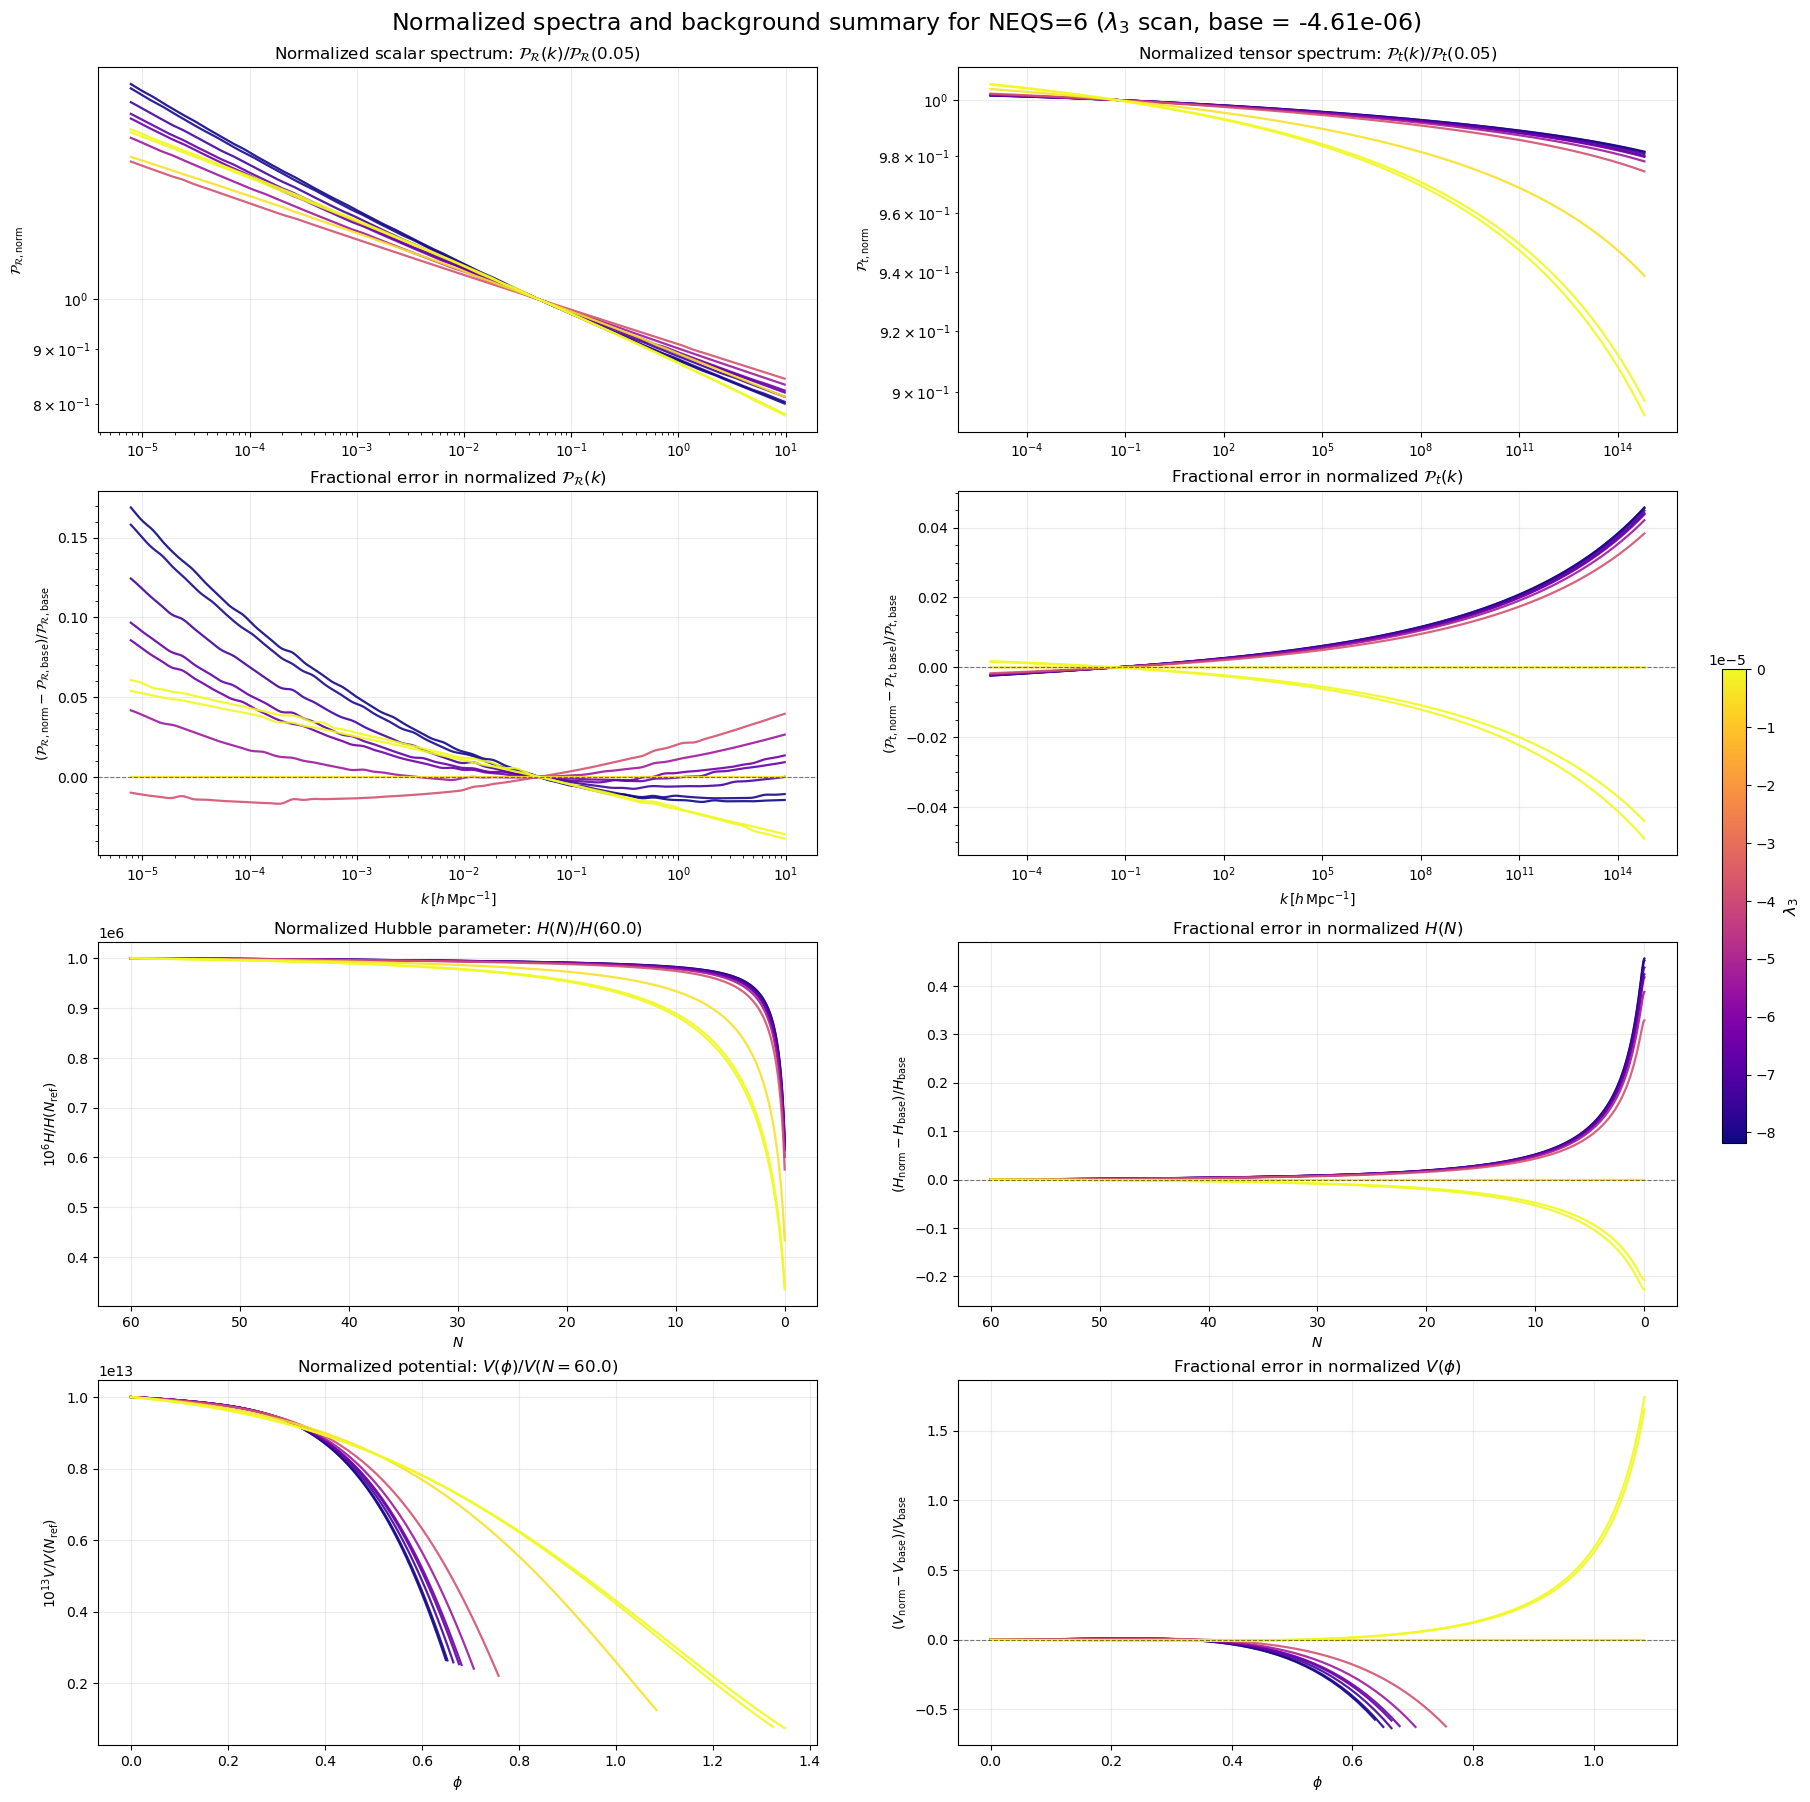

phi at max N: 0.0
phi at min N: 1.084339
           lamX  mean_dPt_pct  max_dPt_pct  mean_dPs_pct  max_dPs_pct  \
0 -8.181654e-05      1.032426     4.575003      3.758263    16.883392   
1 -7.978910e-05      1.027530     4.555221      3.488104    15.800143   
2 -7.296435e-05      1.009813     4.482700      2.762755    12.432524   
3 -6.705256e-05      0.992596     4.411102      2.207146     9.661417   
4 -6.454758e-05      0.984679     4.377798      1.971588     8.561551   
5 -5.385109e-05      0.945302     4.209841      1.088833     4.172522   
6 -3.787876e-05      0.859083     3.833244     -0.047111     3.955280   
7 -4.609710e-06      0.000000     0.000000      0.000000     0.000000   
8 -2.163669e-07     -0.981308     4.393500      1.061457     5.389228   
9  0.000000e+00     -1.093463     4.897367      1.218883     6.061154   

   mean_dH_pct  max_dH_pct  mean_dV_pct  max_dV_pct  
0    18.872000   45.735368    -8.362838   57.292084  
1    18.728920   45.324335    -9.280685   62.50

In [37]:

base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"
lam3_values = get_param_values_from_dirs(6, "lam3", base_path_root)


stats_df = plot_big_normalized_scan_summary(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6097100000e-6,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    index=0,
    k_ref=0.05,
    N_ref=60.0,
    H_scale=1e6,    
    V_scale=1e13,    
    save_name="expanded_neqs6_lam3_big_summary.png"
)

print(stats_df)


Ndiag_df = load_native_N_diagnostics(
    NEQS=6,
    lamX_values=lam3_values,
    base_path_root=base_path_root
)

print(Ndiag_df.to_string(index=False))




In [38]:
summary_file = f"{base_path_root}/neqs6/neqs6_summary.csv"
summary_df = pd.read_csv(summary_file)

cols = [
    "lam3",
    "n_s",
    "r",
    "original_N_end",
    "original_N_before_end",
    "original_N_after_end",
    "original_eps_end",
    "spectrum_N_start",
    "path_N_end",
]

print(summary_df[cols].sort_values("lam3").to_string(index=False))

         lam3      n_s        r  original_N_end  original_N_before_end  original_N_after_end  original_eps_end  spectrum_N_start  path_N_end
-8.181654e-05 0.946531 0.001375      963.026274             963.026274            963.026274               1.0          0.000156        60.0
-7.978910e-05 0.947591 0.001399      962.809067             962.809067            962.809066               1.0          0.000156        60.0
-7.296435e-05 0.951094 0.001481      962.031223             962.031223            962.031223               1.0          0.000157        60.0
-6.705256e-05 0.954029 0.001556      961.291076             961.291076            961.291076               1.0          0.000156        60.0
-6.454758e-05 0.955239 0.001588      960.956069             960.956069            960.956069               1.0          0.000181        60.0
-5.385109e-05 0.960119 0.001735      959.351017             959.351017            959.351017               1.0          0.000156        60.0
-3.787876e-05

In [39]:
print("\nOriginal N-end spread:")
print(summary_df["original_N_end"].describe())

print("\nRange:")
print(summary_df["original_N_end"].max() - summary_df["original_N_end"].min())


Original N-end spread:
count     10.000000
mean     952.422043
std       13.886373
min      929.312981
25%      943.422738
50%      960.153543
75%      961.846186
max      963.026274
Name: original_N_end, dtype: float64

Range:
33.71329305128597


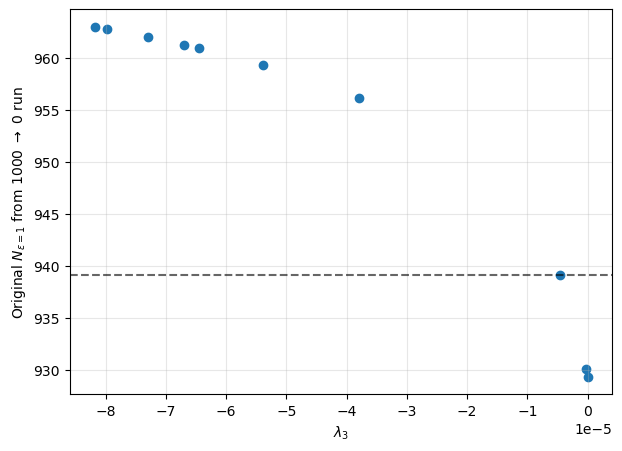

In [40]:
plt.figure(figsize=(7,5))
plt.scatter(summary_df["lam3"], summary_df["original_N_end"])
plt.axhline(summary_df.loc[np.argmin(np.abs(summary_df["lam3"] - (-4.60971e-6))), "original_N_end"],
            ls="--", color="black", alpha=0.6)
plt.xlabel(r"$\lambda_3$")
plt.ylabel(r"Original $N_{\epsilon=1}$ from 1000 $\rightarrow$ 0 run")
plt.grid(True, alpha=0.3)
plt.show()

         lam3      n_s        r  original_N_end  original_N_total
-8.181654e-05 0.946531 0.001375      963.026274         36.973726
-7.978910e-05 0.947591 0.001399      962.809067         37.190933
-7.296435e-05 0.951094 0.001481      962.031223         37.968777
-6.705256e-05 0.954029 0.001556      961.291076         38.708924
-6.454758e-05 0.955239 0.001588      960.956069         39.043931
-5.385109e-05 0.960119 0.001735      959.351017         40.648983
-3.787876e-05 0.966154 0.001990      956.200236         43.799764
-4.609710e-06 0.965678 0.003454      939.163572         60.836428
-2.163669e-07 0.959707 0.004843      930.078918         69.921082
 0.000000e+00 0.959171 0.004996      929.312981         70.687019


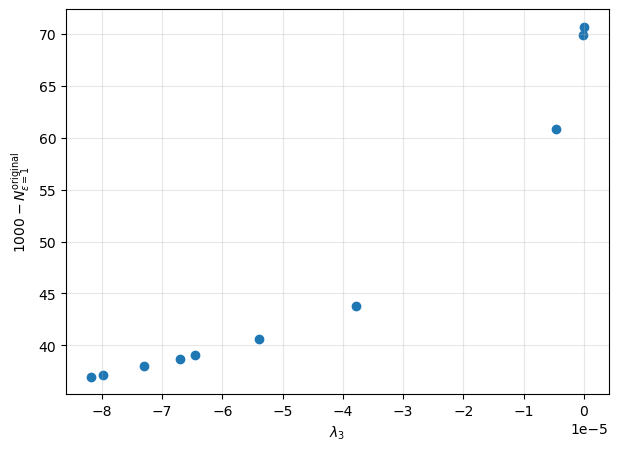

In [41]:
summary_df["original_N_total"] = 1000.0 - summary_df["original_N_end"]

print(summary_df[[
    "lam3", "n_s", "r",
    "original_N_end",
    "original_N_total"
]].sort_values("lam3").to_string(index=False))

plt.figure(figsize=(7,5))
plt.scatter(summary_df["lam3"], summary_df["original_N_total"])
plt.xlabel(r"$\lambda_3$")
plt.ylabel(r"$1000 - N_{\epsilon=1}^{\rm original}$")
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
stats_df["lam3_key"] = stats_df["lamX"].map(lambda x: f"{x:.10e}")
summary_df["lam3_key"] = summary_df["lam3"].map(lambda x: f"{x:.10e}")

merged = stats_df.merge(
    summary_df,
    on="lam3_key",
    how="inner",
    suffixes=("_stats", "_summary")
)

print("stats rows:", len(stats_df))
print("summary rows:", len(summary_df))
print("merged rows:", len(merged))

cols = [
    "lamX",
    "n_s",
    "mean_dPs_pct",
    "max_dPs_pct",
    "mean_dPt_pct",
    "max_dPt_pct",
    "original_N_end"
]

print(
    merged[cols]
    .sort_values("original_N_end")
    .to_string(index=False)
)




stats rows: 10
summary rows: 10
merged rows: 10
         lamX      n_s  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct  original_N_end
 0.000000e+00 0.959171      1.218883     6.061154     -1.093463     4.897367      929.312981
-2.163669e-07 0.959707      1.061457     5.389228     -0.981308     4.393500      930.078918
-4.609710e-06 0.965678      0.000000     0.000000      0.000000     0.000000      939.163572
-3.787876e-05 0.966154     -0.047111     3.955280      0.859083     3.833244      956.200236
-5.385109e-05 0.960119      1.088833     4.172522      0.945302     4.209841      959.351017
-6.454758e-05 0.955239      1.971588     8.561551      0.984679     4.377798      960.956069
-6.705256e-05 0.954029      2.207146     9.661417      0.992596     4.411102      961.291076
-7.296435e-05 0.951094      2.762755    12.432524      1.009813     4.482700      962.031223
-7.978910e-05 0.947591      3.488104    15.800143      1.027530     4.555221      962.809067
-8.181654e-05 0.946531

Spectral spread increases as the original end-of-inflation location shifts away from the base model!!

merged rows: 10
Index(['lamX', 'mean_dPt_pct', 'max_dPt_pct', 'mean_dPs_pct', 'max_dPs_pct',
       'mean_dH_pct', 'max_dH_pct', 'mean_dV_pct', 'max_dV_pct', 'lam3_key',
       'accepted_index', 'trial_index', 'lam3', 'r', 'n_s', 'alpha_s',
       'Nefolds', 'original_end_index', 'original_N_end',
       'original_N_before_end', 'original_N_after_end', 'original_eps_end',
       'spectrum_N_start', 'path_N_end', 'calc_ret', 'outdir',
       'original_N_total', 'lamX_Ndiag', 'N_min', 'N_max', 'N_first', 'N_3',
       'N_last', 'npoints', 'eps_first', 'eps_3', 'eps_last', 'sig_3',
       'lam2_3'],
      dtype='str')


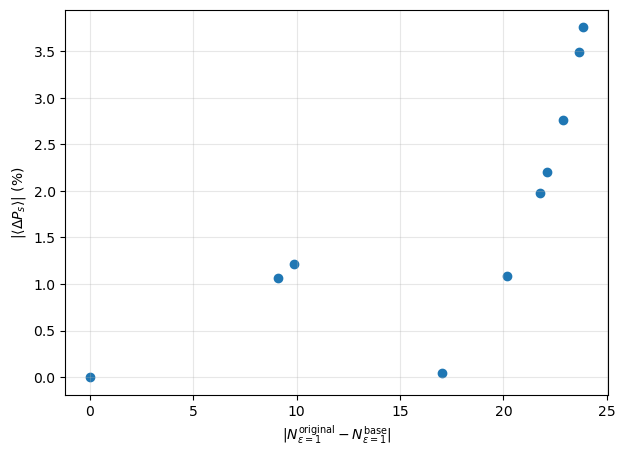

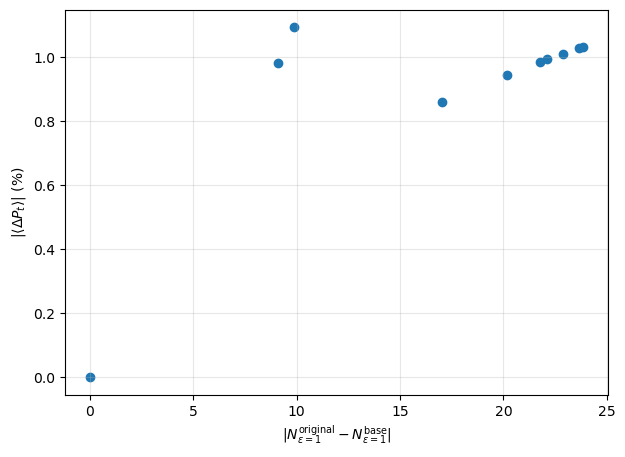

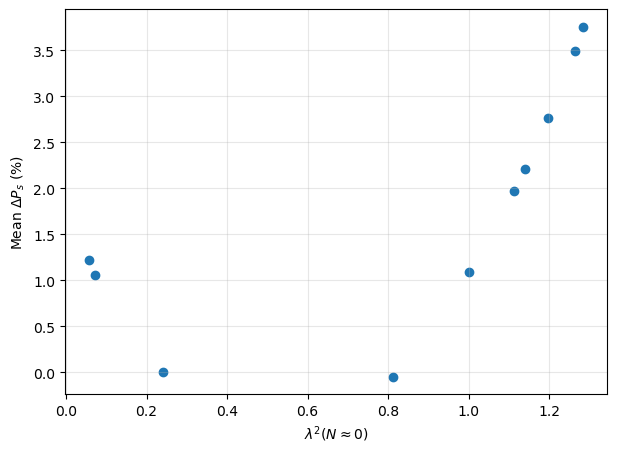

In [45]:
# Make consistent string keys
stats_df["lam3_key"] = stats_df["lamX"].map(lambda x: f"{x:.10e}")
summary_df["lam3_key"] = summary_df["lam3"].map(lambda x: f"{x:.10e}")
Ndiag_df["lam3_key"] = Ndiag_df["lamX"].map(lambda x: f"{x:.10e}")

# Merge spectra + original N diagnostics + native path diagnostics
merged = (
    stats_df
    .merge(summary_df, on="lam3_key", how="inner", suffixes=("_stats", "_summary"))
    .merge(Ndiag_df, on="lam3_key", how="inner", suffixes=("", "_Ndiag"))
)

print("merged rows:", len(merged))
print(merged.columns)

#merge!!

base_lam3 = -4.6097100000e-6

base_idx = np.argmin(np.abs(merged["lamX"] - base_lam3))
base_N_end = merged.iloc[base_idx]["original_N_end"]

merged["delta_original_N_end_from_base"] = (
    merged["original_N_end"] - base_N_end
)

merged["abs_delta_original_N_end_from_base"] = np.abs(
    merged["delta_original_N_end_from_base"]
)

merged["abs_mean_dPs_pct"] = np.abs(merged["mean_dPs_pct"])
merged["abs_mean_dPt_pct"] = np.abs(merged["mean_dPt_pct"])


#plots
plt.figure(figsize=(7,5))
plt.scatter(
    merged["abs_delta_original_N_end_from_base"],
    merged["abs_mean_dPs_pct"]
)
plt.xlabel(r"$|N_{\epsilon=1}^{\rm original} - N_{\epsilon=1}^{\rm base}|$")
plt.ylabel(r"$|\langle \Delta P_s \rangle|$ (%)")
plt.grid(True, alpha=0.3)
plt.show()


plt.figure(figsize=(7,5))
plt.scatter(
    merged["abs_delta_original_N_end_from_base"],
    merged["abs_mean_dPt_pct"]
)
plt.xlabel(r"$|N_{\epsilon=1}^{\rm original} - N_{\epsilon=1}^{\rm base}|$")
plt.ylabel(r"$|\langle \Delta P_t \rangle|$ (%)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7,5))
plt.scatter(merged["lam2_3"], merged["mean_dPs_pct"])
plt.xlabel(r"$\lambda^2(N \approx 0)$")
plt.ylabel(r"Mean $\Delta P_s$ (%)")
plt.grid(True, alpha=0.3)
plt.show()

In [44]:
print(
    merged[[
        "lamX",
        "n_s",
        "original_N_end",
        "delta_original_N_end_from_base",
        "mean_dPs_pct",
        "max_dPs_pct",
        "mean_dPt_pct",
        "max_dPt_pct",
        "sig_3",
        "lam2_3",
    ]]
    .sort_values("delta_original_N_end_from_base")
    .to_string(index=False)
)

         lamX      n_s  original_N_end  delta_original_N_end_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct     sig_3   lam2_3
 0.000000e+00 0.959171      929.312981                       -9.850591      1.218883     6.061154     -1.093463     4.897367 -4.670918 0.057800
-2.163669e-07 0.959707      930.078918                       -9.084655      1.061457     5.389228     -0.981308     4.393500 -4.713827 0.070994
-4.609710e-06 0.965678      939.163572                        0.000000      0.000000     0.000000      0.000000     0.000000 -5.175481 0.240748
-3.787876e-05 0.966154      956.200236                       17.036664     -0.047111     3.955280      0.859083     3.833244 -6.154351 0.811914
-5.385109e-05 0.960119      959.351017                       20.187445      1.088833     4.172522      0.945302     4.209841 -6.394598 1.000113
-6.454758e-05 0.955239      960.956069                       21.792497      1.971588     8.561551      0.984679     4.377798 -6.528642 1

In [54]:
def plot_shifted_flow_overlay(merged, NEQS, base_path_root, base_lam3=-4.6097100000e-6):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def path_file(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")
        return os.path.join(folder, f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")

    def load_path(lam):
        data = pd.read_csv(path_file(lam), sep=r"\s+", header=None).values
        phi = data[:, 0]
        H = data[:, 1]
        eps = data[:, 2]
        sigma = data[:, 3]
        lam2 = data[:, 4]
        N = data[:, NEQS]
        V = data[:, NEQS + 1]
        return N, phi, H, eps, sigma, lam2, V

    base_idx = np.argmin(np.abs(merged["lamX"] - base_lam3))
    base_row = merged.iloc[base_idx]
    base_N_end = base_row["original_N_end"]

    N_base, phi_base, H_base, eps_base, sigma_base, lam2_base, V_base = load_path(base_lam3)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

    ax_eps, ax_sigma = axes[0]
    ax_lam2, ax_H = axes[1]

    # Base curves
    ax_eps.plot(N_base, eps_base, color="black", lw=3, ls="--", label="base")
    ax_sigma.plot(N_base, sigma_base, color="black", lw=3, ls="--", label="base")
    ax_lam2.plot(N_base, lam2_base, color="black", lw=3, ls="--", label="base")
    ax_H.plot(N_base, H_base / np.interp(60.0, N_base, H_base), color="black", lw=3, ls="--", label="base")

    for _, row in merged.iterrows():
        lam = row["lamX"]
        if np.isclose(lam, base_lam3):
            continue

        N, phi, H, eps, sigma, lam2, V = load_path(lam)

        deltaN = row["original_N_end"] - base_N_end
        N_shifted = N + deltaN

        label = rf"$\lambda_3={lam:.1e}$, $\Delta N={deltaN:.1f}$"

        ax_eps.plot(N_shifted, eps, lw=1.4, alpha=0.75, label=label)
        ax_sigma.plot(N_shifted, sigma, lw=1.4, alpha=0.75)
        ax_lam2.plot(N_shifted, lam2, lw=1.4, alpha=0.75)
        ax_H.plot(N_shifted, H / np.interp(60.0, N, H), lw=1.4, alpha=0.75)

    ax_eps.set_title(r"$\epsilon(N+\Delta N)$")
    ax_sigma.set_title(r"$\sigma(N+\Delta N)$")
    ax_lam2.set_title(r"$\lambda_2(N+\Delta N)$")
    ax_H.set_title(r"$H(N+\Delta N)/H(60)$")

    ax_eps.set_yscale("log")

    for ax in axes.ravel():
        ax.set_xlabel(r"Shifted $N$")
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()

    ax_eps.legend(fontsize=7)

    fig.suptitle(
        r"Testing whether varying $\lambda_3$ acts like an $N$-shift",
        fontsize=15
    )

    plt.show()

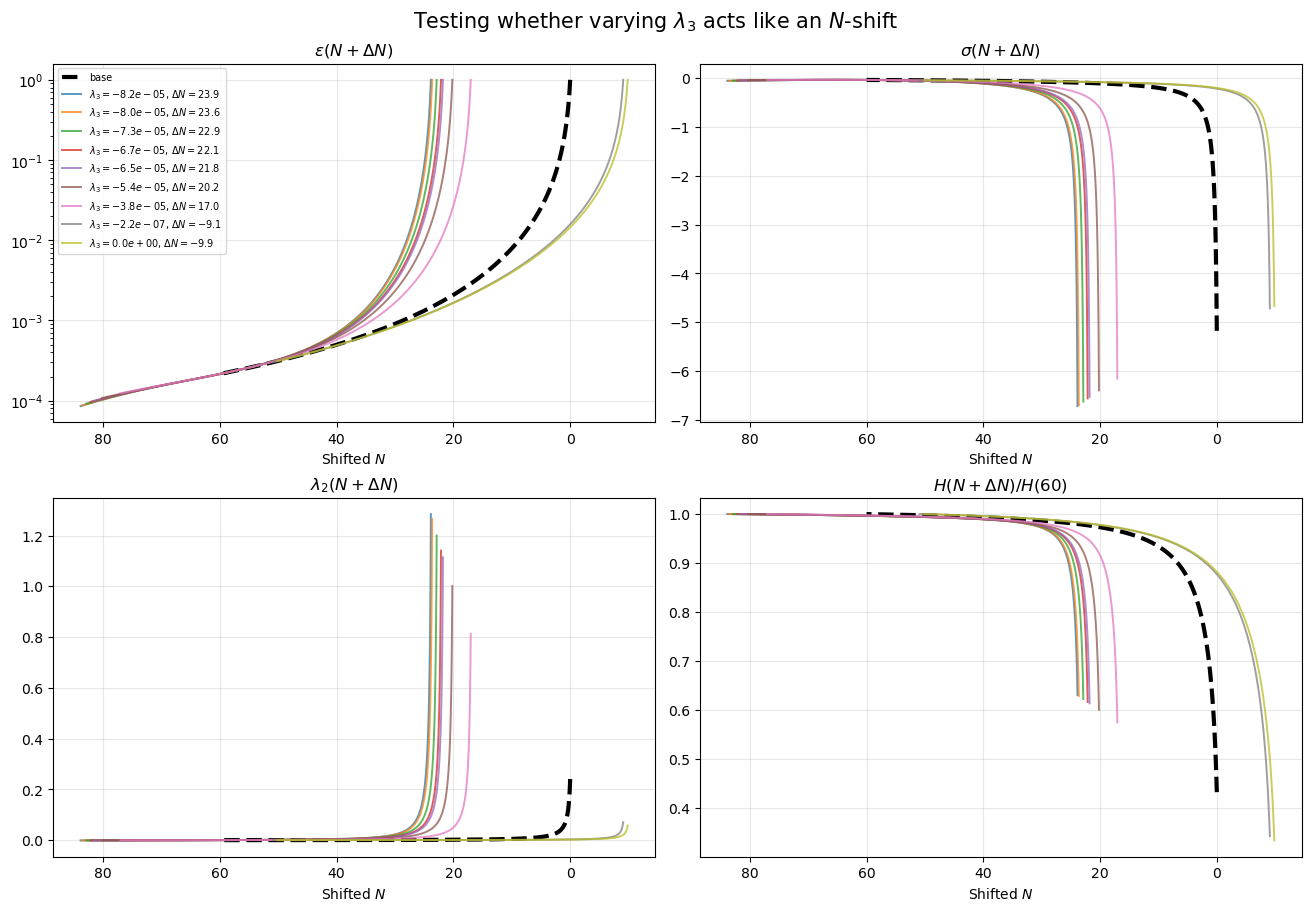

In [55]:
plot_shifted_flow_overlay(
    merged=merged,
    NEQS=6,
    base_path_root=base_path_root,
    base_lam3=-4.6097100000e-6
)

In [56]:
def compute_shift_alignment_table(merged, NEQS, base_path_root, base_lam3):
    import os
    import numpy as np
    import pandas as pd

    scan_name, _ = SCAN_INFO[NEQS]

    def path_file(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")
        return os.path.join(folder, f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")

    def load_path(lam):
        data = pd.read_csv(path_file(lam), sep=r"\s+", header=None).values

        N = data[:, NEQS]
        eps = data[:, 2]
        sigma = data[:, 3]
        lam2 = data[:, 4]

        # Make sure N is increasing for np.interp
        order = np.argsort(N)
        return N[order], eps[order], sigma[order], lam2[order]

    def rms_on_overlap(N_base, y_base, N_model, y_model):
        xmin = max(np.min(N_base), np.min(N_model))
        xmax = min(np.max(N_base), np.max(N_model))

        mask = (N_base >= xmin) & (N_base <= xmax)

        if np.sum(mask) < 5:
            return np.nan, np.sum(mask), xmin, xmax

        y_interp = np.interp(N_base[mask], N_model, y_model)
        rms = np.sqrt(np.mean((y_interp - y_base[mask])**2))

        return rms, np.sum(mask), xmin, xmax

    # Base model
    base_idx = np.argmin(np.abs(merged["lamX"] - base_lam3))
    base_row = merged.iloc[base_idx]
    base_N_end = base_row["original_N_end"]

    N_base, eps_base, sig_base, lam2_base = load_path(base_lam3)

    rows = []

    for _, row in merged.iterrows():
        lam = row["lamX"]
        deltaN = row["original_N_end"] - base_N_end

        N, eps, sig, lam2 = load_path(lam)

        # No shift
        rms_eps_before, n_before, xmin_before, xmax_before = rms_on_overlap(
            N_base, eps_base, N, eps
        )
        rms_sig_before, _, _, _ = rms_on_overlap(
            N_base, sig_base, N, sig
        )
        rms_lam2_before, _, _, _ = rms_on_overlap(
            N_base, lam2_base, N, lam2
        )

        # Plus shift
        N_plus = N + deltaN

        rms_eps_plus, n_plus, xmin_plus, xmax_plus = rms_on_overlap(
            N_base, eps_base, N_plus, eps
        )
        rms_sig_plus, _, _, _ = rms_on_overlap(
            N_base, sig_base, N_plus, sig
        )
        rms_lam2_plus, _, _, _ = rms_on_overlap(
            N_base, lam2_base, N_plus, lam2
        )

        # Minus shift
        N_minus = N - deltaN

        rms_eps_minus, n_minus, xmin_minus, xmax_minus = rms_on_overlap(
            N_base, eps_base, N_minus, eps
        )
        rms_sig_minus, _, _, _ = rms_on_overlap(
            N_base, sig_base, N_minus, sig
        )
        rms_lam2_minus, _, _, _ = rms_on_overlap(
            N_base, lam2_base, N_minus, lam2
        )

        rows.append({
            "lam3": lam,
            "delta_N": deltaN,

            "rms_eps_before": rms_eps_before,
            "rms_eps_plus": rms_eps_plus,
            "rms_eps_minus": rms_eps_minus,

            "rms_sigma_before": rms_sig_before,
            "rms_sigma_plus": rms_sig_plus,
            "rms_sigma_minus": rms_sig_minus,

            "rms_lam2_before": rms_lam2_before,
            "rms_lam2_plus": rms_lam2_plus,
            "rms_lam2_minus": rms_lam2_minus,

            "n_overlap_before": n_before,
            "n_overlap_plus": n_plus,
            "n_overlap_minus": n_minus,

            "N_overlap_before": f"[{xmin_before:.3f}, {xmax_before:.3f}]",
            "N_overlap_plus": f"[{xmin_plus:.3f}, {xmax_plus:.3f}]",
            "N_overlap_minus": f"[{xmin_minus:.3f}, {xmax_minus:.3f}]",
        })

    return pd.DataFrame(rows).sort_values("delta_N")

In [57]:
alignment_df = compute_shift_alignment_table(
    merged,
    NEQS=6,
    base_path_root=base_path_root,
    base_lam3=-4.6097100000e-6
)

print(alignment_df.to_string(index=False))

         lam3   delta_N  rms_eps_before  rms_eps_plus  rms_eps_minus  rms_sigma_before  rms_sigma_plus  rms_sigma_minus  rms_lam2_before  rms_lam2_plus  rms_lam2_minus  n_overlap_before  n_overlap_plus  n_overlap_minus N_overlap_before   N_overlap_plus N_overlap_minus
 0.000000e+00 -9.850591        0.028201      0.365608       0.074765          0.158876        1.921507         0.370757         0.068832       0.092398        0.004131                98              94               33  [0.000, 60.000]  [0.000, 50.149] [9.851, 60.000]
-2.163669e-07 -9.084655        0.025615      0.364934       0.129823          0.145399        1.913870         0.616959         0.063766       0.092130        0.008751                98              94               35  [0.000, 60.000]  [0.000, 50.915] [9.085, 60.000]
-4.609710e-06  0.000000        0.000000      0.000000       0.000000          0.000000        0.000000         0.000000         0.000000       0.000000        0.000000                98        

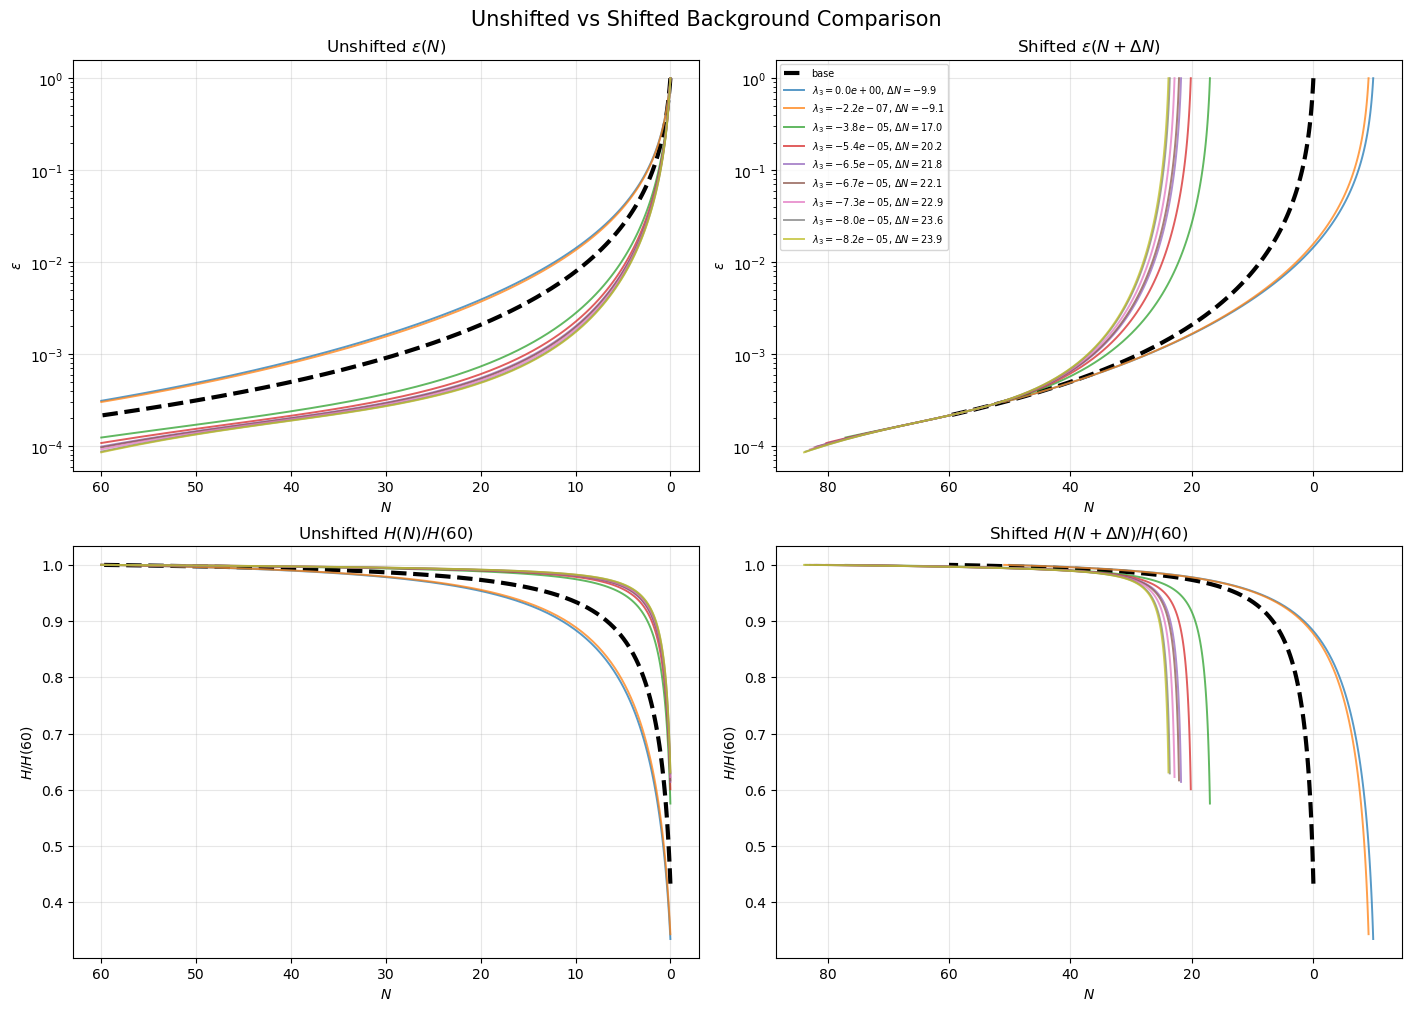

In [62]:
def plot_unshifted_vs_shifted_eps_H(merged, NEQS, base_path_root, base_lam3=-4.6097100000e-6):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    scan_name, _ = SCAN_INFO[NEQS]

    def load_path(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")
        file_path = os.path.join(folder, f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        data = pd.read_csv(file_path, sep=r"\s+", header=None).values

        N = data[:, NEQS]
        eps = data[:, 2]
        H = data[:, 1]

        # sort for safety
        order = np.argsort(N)
        return N[order], eps[order], H[order]

    base_idx = np.argmin(np.abs(merged["lamX"] - base_lam3))
    base_N_end = merged.iloc[base_idx]["original_N_end"]

    N_base, eps_base, H_base = load_path(base_lam3)

    # normalize H at N=60
    H_base_norm = H_base / np.interp(60.0, N_base, H_base)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

    ax_eps_un, ax_eps_sh = axes[0]
    ax_H_un, ax_H_sh = axes[1]

    # base curves
    ax_eps_un.plot(N_base, eps_base, color="black", lw=3, ls="--", label="base")
    ax_eps_sh.plot(N_base, eps_base, color="black", lw=3, ls="--", label="base")

    ax_H_un.plot(N_base, H_base_norm, color="black", lw=3, ls="--", label="base")
    ax_H_sh.plot(N_base, H_base_norm, color="black", lw=3, ls="--", label="base")

    for _, row in merged.sort_values("delta_original_N_end_from_base").iterrows():
        lam = row["lamX"]
        if np.isclose(lam, base_lam3):
            continue

        N, eps, H = load_path(lam)

        deltaN = row["original_N_end"] - base_N_end

        # normalize each model's H at its own N=60
        H_norm = H / np.interp(60.0, N, H)

        # unshifted
        ax_eps_un.plot(N, eps, lw=1.4, alpha=0.75)
        ax_H_un.plot(N, H_norm, lw=1.4, alpha=0.75)

        # shifted
        ax_eps_sh.plot(N + deltaN, eps, lw=1.4, alpha=0.75,
                       label=rf"$\lambda_3={lam:.1e}$, $\Delta N={deltaN:.1f}$")

        ax_H_sh.plot(N + deltaN, H_norm, lw=1.4, alpha=0.75)

    # titles
    ax_eps_un.set_title(r"Unshifted $\epsilon(N)$")
    ax_eps_sh.set_title(r"Shifted $\epsilon(N+\Delta N)$")

    ax_H_un.set_title(r"Unshifted $H(N)/H(60)$")
    ax_H_sh.set_title(r"Shifted $H(N+\Delta N)/H(60)$")

    # formatting
    for ax in [ax_eps_un, ax_eps_sh]:
        ax.set_yscale("log")
        ax.set_ylabel(r"$\epsilon$")

    for ax in [ax_H_un, ax_H_sh]:
        ax.set_ylabel(r"$H/H(60)$")

    for ax in axes.ravel():
        ax.set_xlabel(r"$N$")
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()

    ax_eps_sh.legend(fontsize=7)

    fig.suptitle("Unshifted vs Shifted Background Comparison", fontsize=15)

    plt.show()
    
    
plot_unshifted_vs_shifted_eps_H(
    merged=merged,
    NEQS=6,
    base_path_root=base_path_root,
    base_lam3=-4.6097100000e-6
)


I have two timelines coordinates: one which goes from some arbitrary number 1000 e-folds to 0, where Nend would happen where epsilon=1.Then I have the reconstructed path where N=60 down to N=0 which is forced upon all models.

For each model I want to know what happens when I change lambda3. I need to determine if I am moving along the same inflationary trajectory in e-fold time (N) or if I am actually changing the physics.So the plots on the left are as they appear in the code, these are the reconstructed pathways. They run such that the end of inflation is marked at N=0, and I am only tracing back 60 e-folds from there. 

In the plots on the right, the second column, I find where inflation ended originally for that model and subtract where it ended for the base model which in this case is like 939.163572 e-folds. So some of these will look like 956 is where the model ended, so let's find how much different that is from the base with ΔN, and then shift it by that amount to see how well it lines up with the base model. So it is like N = N_reconstructed + ΔN.

I am undoing that artificial alignment but I am not seeing these guys perfectly line up with the base model. It's like as I restore the original positions in N, I am not seeing the trajectories exactly line up. 

The plots on the right has them appearing shifted but they are not all collapsing onto the base. Ultimately here I am testing whether varying λ₃ simply shifts the inflationary trajectory in e-fold time or alters its dynamics, but maybe it is a bit of both??


In [60]:
merged["abs_delta_N"] = np.abs(merged["delta_original_N_end_from_base"])
merged["abs_mean_dPs_pct"] = np.abs(merged["mean_dPs_pct"])
merged["abs_mean_dPt_pct"] = np.abs(merged["mean_dPt_pct"])
merged["abs_max_dPs_pct"] = np.abs(merged["max_dPs_pct"])
merged["abs_max_dPt_pct"] = np.abs(merged["max_dPt_pct"])

print(
    merged[[
        "lamX",
        "n_s",
        "delta_original_N_end_from_base",
        "abs_delta_N",
        "mean_dPs_pct",
        "max_dPs_pct",
        "mean_dPt_pct",
        "max_dPt_pct",
    ]]
    .sort_values("abs_delta_N")
    .to_string(index=False)
)


print(
    merged[[
        "abs_delta_N",
        "abs_mean_dPs_pct",
        "abs_max_dPs_pct",
        "abs_mean_dPt_pct",
        "abs_max_dPt_pct",
    ]].corr()
)

         lamX      n_s  delta_original_N_end_from_base  abs_delta_N  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-4.609710e-06 0.965678                        0.000000     0.000000      0.000000     0.000000      0.000000     0.000000
-2.163669e-07 0.959707                       -9.084655     9.084655      1.061457     5.389228     -0.981308     4.393500
 0.000000e+00 0.959171                       -9.850591     9.850591      1.218883     6.061154     -1.093463     4.897367
-3.787876e-05 0.966154                       17.036664    17.036664     -0.047111     3.955280      0.859083     3.833244
-5.385109e-05 0.960119                       20.187445    20.187445      1.088833     4.172522      0.945302     4.209841
-6.454758e-05 0.955239                       21.792497    21.792497      1.971588     8.561551      0.984679     4.377798
-6.705256e-05 0.954029                       22.127503    22.127503      2.207146     9.661417      0.992596     4.411102
-7.296435e-05 0.951094  

In [68]:
def plot_restored_original_trajectories(
    merged,
    NEQS,
    base_path_root,
    base_lam3=-4.6097100000e-6
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    scan_name, _ = SCAN_INFO[NEQS]

    def load_path(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")
        file_path = os.path.join(folder, f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        data = pd.read_csv(file_path, sep=r"\s+", header=None).values

        N = data[:, NEQS]
        eps = data[:, 2]
        sigma = data[:, 3]
        lam2 = data[:, 4]
        H = data[:, 1]

        order = np.argsort(N)
        return N[order], eps[order], sigma[order], lam2[order], H[order]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

    ax_eps, ax_sig = axes[0]
    ax_lam2, ax_H = axes[1]

    for _, row in merged.sort_values("original_N_end").iterrows():
        lam = row["lamX"]
        N_recon, eps, sigma, lam2, H = load_path(lam)

        N_restored = row["original_N_end"] + N_recon
        H_norm = H / np.interp(60.0, N_recon, H)
        

        is_base = np.isclose(lam, base_lam3)
        lw = 3.0 if is_base else 1.5
        color = "black" if is_base else None
        ls = "--" if is_base else "-"

        label = (
            rf"base $\lambda_3={lam:.1e}$"
            if is_base else
            rf"$\lambda_3={lam:.1e}$"
        )

        ax_eps.plot(N_restored, eps, lw=lw, ls=ls, color=color, alpha=0.8, label=label)
        ax_sig.plot(N_restored, sigma, lw=lw, ls=ls, color=color, alpha=0.8)
        ax_lam2.plot(N_restored, lam2, lw=lw, ls=ls, color=color, alpha=0.8)
        ax_H.plot(N_restored, H_norm, lw=lw, ls=ls, color=color, alpha=0.8)

    ax_eps.set_title(r"Restored original-coordinate $\epsilon(N_{\rm orig})$")
    ax_sig.set_title(r"Restored original-coordinate $\sigma(N_{\rm orig})$")
    ax_lam2.set_title(r"Restored original-coordinate $\lambda_2(N_{\rm orig})$")
    ax_H.set_title(r"Restored original-coordinate $H/H(N_{\rm recon}=60)$")

    ax_eps.set_yscale("log")

    for ax in axes.ravel():
        ax.set_xlabel(r"$N_{\rm orig} \approx N_{\epsilon=1}^{\rm orig} + N_{\rm recon}$")
        ax.set_xlabel(r"Approximate original e-fold coordinate = $N_{\epsilon=1}^{\rm orig} + N_{\rm recon}$")
        ax.grid(True, alpha=0.3)
        ax.invert_xaxis()

    ax_eps.set_ylabel(r"$\epsilon$")
    ax_sig.set_ylabel(r"$\sigma$")
    ax_lam2.set_ylabel(r"$\lambda_2$")
    ax_H.set_ylabel(r"$H/H(60)$")

    ax_eps.legend(fontsize=7)

    fig.suptitle(
        r"Approximate restoration of each model's original e-fold coordinate",
        fontsize=15
    )

    plt.show()

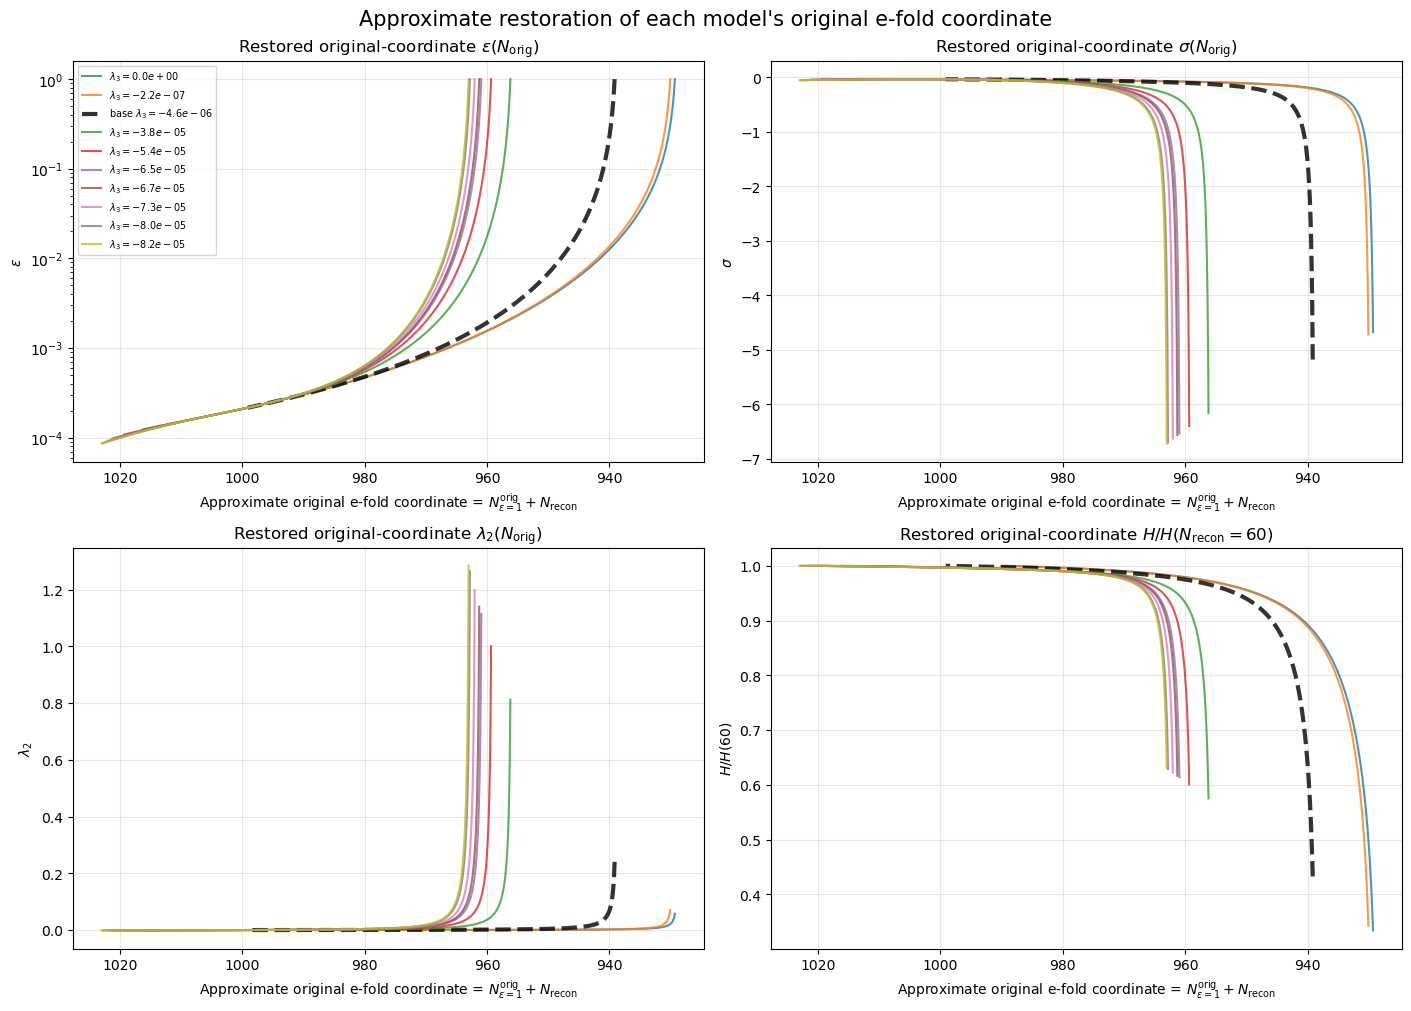

In [69]:
plot_restored_original_trajectories(
    merged=merged,
    NEQS=6,
    base_path_root=base_path_root,
    base_lam3=-4.6097100000e-6
)

#The x-axis represents an approximate reconstruction of the original e-fold time, 
#obtained by offsetting each model’s last 60 e-fold trajectory by its original end-of-inflation location.
#That way it may be easier to read off and is not so focused on what is happening relative to the base model

Are these the same shape?? 

In [71]:
def plot_shape_fractional_error(
    merged,
    NEQS,
    base_path_root,
    base_lam3=-4.6097100000e-6
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    scan_name, _ = SCAN_INFO[NEQS]

    def load_path(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")
        file_path = os.path.join(folder, f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        data = pd.read_csv(file_path, sep=r"\s+", header=None).values

        N = data[:, NEQS]
        eps = data[:, 2]

        order = np.argsort(N)
        return N[order], eps[order]

    # base model
    base_idx = np.argmin(np.abs(merged["lamX"] - base_lam3))
    base_row = merged.iloc[base_idx]

    N_base, eps_base = load_path(base_lam3)
    N_base_restored = base_row["original_N_end"] + N_base

    plt.figure(figsize=(7,5))

    for _, row in merged.iterrows():
        lam = row["lamX"]
        if np.isclose(lam, base_lam3):
            continue

        N, eps = load_path(lam)
        N_restored = row["original_N_end"] + N

        # overlap region
        xmin = max(N_base_restored.min(), N_restored.min())
        xmax = min(N_base_restored.max(), N_restored.max())

        mask = (N_base_restored >= xmin) & (N_base_restored <= xmax)

        if np.sum(mask) < 10:
            continue

        eps_interp = np.interp(N_base_restored[mask], N_restored, eps)

        frac_err = (eps_interp - eps_base[mask]) / eps_base[mask]

        plt.plot(
            N_base_restored[mask],
            frac_err,
            label=rf"$\lambda_3={lam:.1e}$",
            alpha=0.8
        )

    plt.axhline(0, color="black", ls="--", alpha=0.6)

    plt.xlabel(r"Approximate original e-fold coordinate")
    plt.ylabel(r"Fractional difference in $\epsilon$")
    plt.title("Shape comparison after restoring original N")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=7)

    plt.show()

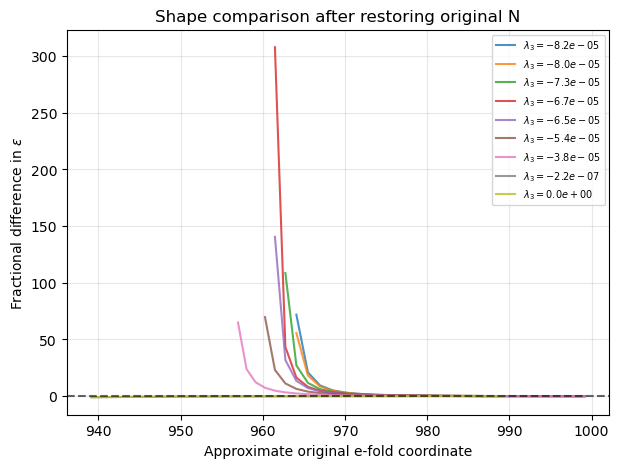

In [72]:
plot_shape_fractional_error(
    merged=merged,
    NEQS=6,
    base_path_root=base_path_root,
    base_lam3=-4.6097100000e-6
)

In [78]:
def best_fit_N_shift_table(
    merged,
    NEQS,
    base_path_root,
    base_lam3=-4.6097100000e-6,
    shift_min=-40,
    shift_max=40,
    n_shifts=801,
    variable="eps",
):
    import os
    import numpy as np
    import pandas as pd

    scan_name, _ = SCAN_INFO[NEQS]

    colmap = {
        "eps": 2,
        "sigma": 3,
        "lam2": 4,
        "H": 1,
    }

    if variable not in colmap:
        raise ValueError("variable must be one of: eps, sigma, lam2, H")

    var_col = colmap[variable]

    def load_path(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")
        file_path = os.path.join(folder, f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        data = pd.read_csv(file_path, sep=r"\s+", header=None).values

        N = data[:, NEQS]
        y = data[:, var_col]

        order = np.argsort(N)
        N = N[order]
        y = y[order]

        if variable == "H":
            y = y / np.interp(60.0, N, y)

        return N, y

    def rms_on_overlap(N_base, y_base, N_model_shifted, y_model):
        xmin = max(N_base.min(), N_model_shifted.min())
        xmax = min(N_base.max(), N_model_shifted.max())

        mask = (N_base >= xmin) & (N_base <= xmax)

        if np.sum(mask) < 10:
            return np.nan

        y_interp = np.interp(N_base[mask], N_model_shifted, y_model)
        return np.sqrt(np.mean((y_interp - y_base[mask])**2))

    base_idx = np.argmin(np.abs(merged["lamX"] - base_lam3))
    base_N_end = merged.iloc[base_idx]["original_N_end"]

    N_base, y_base = load_path(base_lam3)

    shifts = np.linspace(shift_min, shift_max, n_shifts)

    rows = []

    for _, row in merged.iterrows():
        lam = row["lamX"]
        N, y = load_path(lam)

        rms_vals = []

        for s in shifts:
            rms = rms_on_overlap(N_base, y_base, N + s, y)
            rms_vals.append(rms)

        rms_vals = np.array(rms_vals)

        if np.all(np.isnan(rms_vals)):
            best_shift = np.nan
            best_rms = np.nan
        else:
            best_idx = np.nanargmin(rms_vals)
            best_shift = shifts[best_idx]
            best_rms = rms_vals[best_idx]

        rms_no_shift = rms_on_overlap(N_base, y_base, N, y)

        delta_N_original = row["original_N_end"] - base_N_end

        rows.append({
            "lam3": lam,
            "variable": variable,
            "delta_N_original": delta_N_original,
            "best_fit_shift": best_shift,
            "shift_difference": best_shift - delta_N_original,
            "rms_no_shift": rms_no_shift,
            "rms_best_shift": best_rms,
            "improvement_factor": rms_no_shift / best_rms if best_rms and best_rms > 0 else np.nan,
        })

    return pd.DataFrame(rows).sort_values("delta_N_original")

In [79]:
shift_eps_df = best_fit_N_shift_table(
    merged=merged,
    NEQS=6,
    base_path_root=base_path_root,
    base_lam3=-4.6097100000e-6,
    shift_min=-40,
    shift_max=40,
    n_shifts=801,
    variable="eps",
)

print(shift_eps_df.to_string(index=False))

         lam3 variable  delta_N_original  best_fit_shift  shift_difference  rms_no_shift  rms_best_shift  improvement_factor
 0.000000e+00      eps         -9.850591             0.0          9.850591      0.028201        0.028201            1.000000
-2.163669e-07      eps         -9.084655             0.0          9.084655      0.025615        0.025615            1.000000
-4.609710e-06      eps          0.000000             0.0          0.000000      0.000000        0.000000                 NaN
-3.787876e-05      eps         17.036664            36.5         19.463336      0.041159        0.017910            2.298060
-5.385109e-05      eps         20.187445            36.5         16.312555      0.049261        0.015581            3.161660
-6.454758e-05      eps         21.792497            36.5         14.707503      0.054082        0.014455            3.741473
-6.705256e-05      eps         22.127503            36.5         14.372497      0.054433        0.014217            3.828661


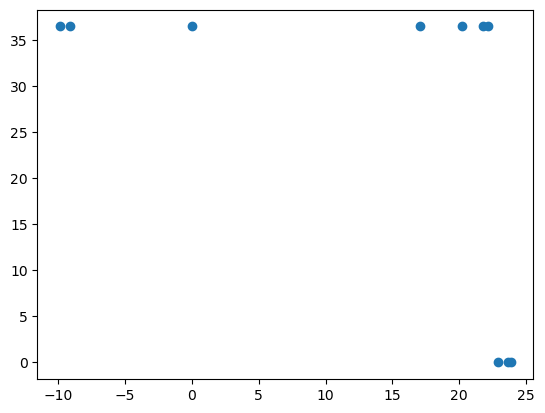

In [82]:
plt.scatter(merged["delta_original_N_end_from_base"], shift_eps_df["best_fit_shift"])


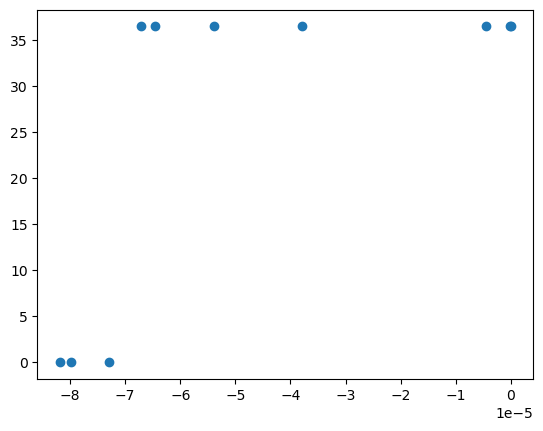

In [83]:
plt.scatter(merged["lamX"], shift_eps_df["best_fit_shift"])

In [86]:
def plot_lambda3_spectra_vs_N(
    merged,
    NEQS,
    base_path_root,
    index=0,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    scan_name, _ = SCAN_INFO[NEQS]

    def load_path(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")
        file_path = os.path.join(folder, f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        return pd.read_csv(file_path, sep=r"\s+", header=None).values

    def load_specs(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        file_s = os.path.join(folder, f"spec_s_neqs{NEQS}.dat")
        file_t = os.path.join(folder, f"spec_t_neqs{NEQS}.dat")

        data_s = np.loadtxt(file_s)
        data_t = np.loadtxt(file_t)

        return data_s[:,0], np.abs(data_s[:,1]), np.abs(data_t[:,1])

    def prepare_increasing(x, y):
        if np.any(np.diff(x) < 0):
            return x[::-1], y[::-1]
        return x, y

    def normalize_at_Nref(N, Y):
        N, Y = prepare_increasing(N, Y)
        Y_ref = np.interp(N_ref, N, Y)
        return N, Y / Y_ref

    fig, axs = plt.subplots(1, 2, figsize=(14,5), constrained_layout=True)

    for _, row in merged.iterrows():
        lam = row["lamX"]

        path = load_path(lam)
        k, Ps_k, Pt_k = load_specs(lam)

        N_path = path[:, NEQS]
        H_path = path[:, 1]

        N_path, H_path = prepare_increasing(N_path, H_path)

        H_ref = np.interp(N_ref, N_path, H_path)

        k_ref = 1.73e-61 / 5.41e-58  # same as your original

        k_cross = k_ref * np.exp(N_ref - N_path) * H_path / H_ref

        mask = (k_cross >= np.min(k)) & (k_cross <= np.max(k))
        N_use = N_path[mask]
        k_use = k_cross[mask]

        Ps_N = np.interp(k_use, k, Ps_k)
        Pt_N = np.interp(k_use, k, Pt_k)

        # normalize
        N_use, Ps_norm = normalize_at_Nref(N_use, Ps_N)
        N_use, Pt_norm = normalize_at_Nref(N_use, Pt_N)

        # restrict window
        mask_window = (N_use >= N_min) & (N_use <= N_max)
        N_plot = N_use[mask_window]

        axs[0].plot(N_plot, Ps_norm[mask_window],
                    label=rf"$\lambda_3={lam:.1e}$", alpha=0.8)

        axs[1].plot(N_plot, Pt_norm[mask_window],
                    label=rf"$\lambda_3={lam:.1e}$", alpha=0.8)

    axs[0].set_title(r"$\mathcal{P}_\mathcal{R}(N)/\mathcal{P}_\mathcal{R}(60)$")
    axs[1].set_title(r"$\mathcal{P}_t(N)/\mathcal{P}_t(60)$")

    for ax in axs:
        ax.set_xlabel(r"$N_{\rm cross}$")
        ax.set_ylabel("Normalized power")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)

    axs[0].legend(fontsize=7)

    plt.show()

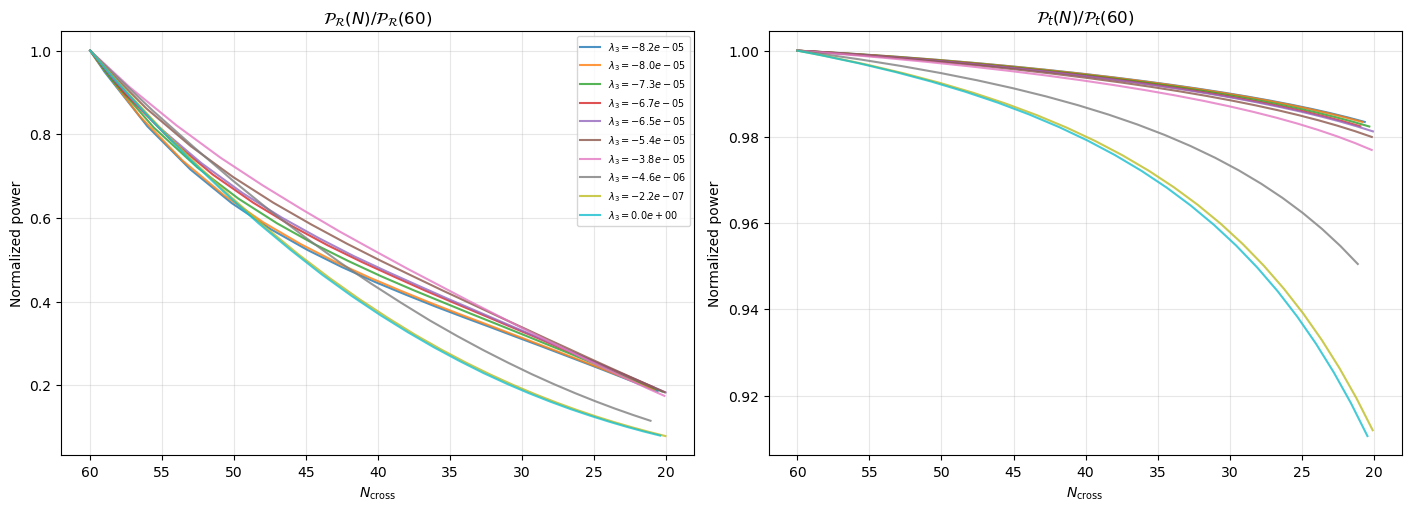

In [87]:
plot_lambda3_spectra_vs_N(
    merged=merged,
    NEQS=6,
    base_path_root=base_path_root,
    index=0,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
)

In [88]:
def plot_lambda3_spectra_vs_restored_N(
    merged,
    NEQS,
    base_path_root,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    scan_name, _ = SCAN_INFO[NEQS]

    def load_path(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")
        file_path = os.path.join(folder, f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        return pd.read_csv(file_path, sep=r"\s+", header=None).values

    def load_specs(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        data_s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        data_t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        return data_s[:, 0], np.abs(data_s[:, 1]), np.abs(data_t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        if np.any(np.diff(x) < 0):
            return x[::-1], y[::-1]
        return x, y

    def normalize_at_Nref(N, Y):
        N, Y = prepare_increasing(N, Y)
        Y_ref = np.interp(N_ref, N, Y)
        return N, Y / Y_ref

    fig, axs = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

    for _, row in merged.iterrows():
        lam = row["lamX"]
        original_N_end = row["original_N_end"]

        path = load_path(lam)
        k, Ps_k, Pt_k = load_specs(lam)

        N_path = path[:, NEQS]
        H_path = path[:, 1]

        N_path, H_path = prepare_increasing(N_path, H_path)

        H_ref = np.interp(N_ref, N_path, H_path)
        k_ref = 1.73e-61 / 5.41e-58

        k_cross = k_ref * np.exp(N_ref - N_path) * H_path / H_ref

        mask = (k_cross >= np.min(k)) & (k_cross <= np.max(k))
        N_use = N_path[mask]
        k_use = k_cross[mask]

        Ps_N = np.interp(k_use, k, Ps_k)
        Pt_N = np.interp(k_use, k, Pt_k)

        N_use, Ps_norm = normalize_at_Nref(N_use, Ps_N)
        _, Pt_norm = normalize_at_Nref(N_use, Pt_N)

        mask_window = (N_use >= N_min) & (N_use <= N_max)

        N_restored_plot = original_N_end + N_use[mask_window]

        axs[0].plot(
            N_restored_plot,
            Ps_norm[mask_window],
            label=rf"$\lambda_3={lam:.1e}$",
            alpha=0.8
        )

        axs[1].plot(
            N_restored_plot,
            Pt_norm[mask_window],
            label=rf"$\lambda_3={lam:.1e}$",
            alpha=0.8
        )

    axs[0].set_title(
        rf"$\mathcal{{P}}_\mathcal{{R}}(N_\mathrm{{orig}})/\mathcal{{P}}_\mathcal{{R}}(N_\mathrm{{recon}}={N_ref})$"
    )
    axs[1].set_title(
        rf"$\mathcal{{P}}_t(N_\mathrm{{orig}})/\mathcal{{P}}_t(N_\mathrm{{recon}}={N_ref})$"
    )

    for ax in axs:
        ax.set_xlabel(r"Approximate original e-fold coordinate")
        ax.set_ylabel("Normalized power")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)

    axs[0].legend(fontsize=7)
    plt.show()

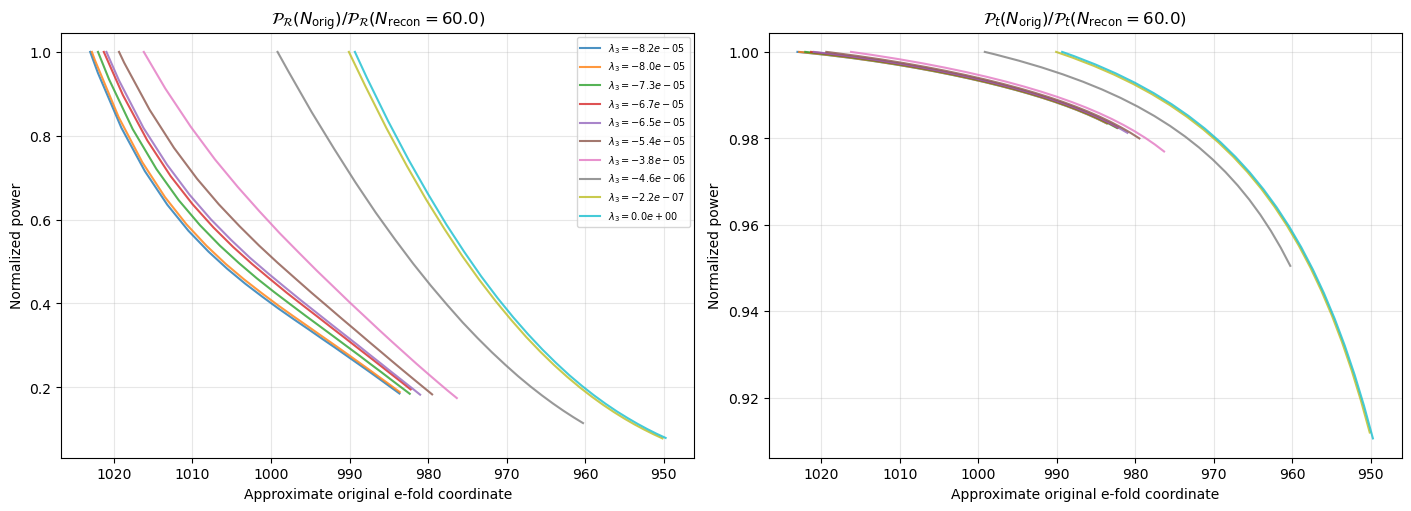

In [89]:
plot_lambda3_spectra_vs_restored_N(
    merged=merged,
    NEQS=6,
    base_path_root=base_path_root,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
)

In [90]:
def plot_lambda3_spectra_vs_restored_N_with_frac_error(
    merged,
    NEQS,
    base_path_root,
    base_lam3=-4.6097100000e-6,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
    frac_floor=1e-100,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    scan_name, _ = SCAN_INFO[NEQS]

    def load_path(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")
        file_path = os.path.join(folder, f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        return pd.read_csv(file_path, sep=r"\s+", header=None).values

    def load_specs(lam):
        val_str = f"{lam:.10e}"
        folder = os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

        data_s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        data_t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        return data_s[:, 0], np.abs(data_s[:, 1]), np.abs(data_t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_Nref(N, Y):
        N, Y = prepare_increasing(N, Y)
        Y_ref = np.interp(N_ref, N, Y)
        return N, Y / Y_ref

    def build_spectra_vs_restored_N(row):
        lam = row["lamX"]
        original_N_end = row["original_N_end"]

        path = load_path(lam)
        k, Ps_k, Pt_k = load_specs(lam)

        N_path = path[:, NEQS]
        H_path = path[:, 1]
        N_path, H_path = prepare_increasing(N_path, H_path)

        H_ref = np.interp(N_ref, N_path, H_path)
        k_ref = 1.73e-61 / 5.41e-58

        k_cross = k_ref * np.exp(N_ref - N_path) * H_path / H_ref

        mask = (k_cross >= np.min(k)) & (k_cross <= np.max(k))
        N_use = N_path[mask]
        k_use = k_cross[mask]

        Ps_N = np.interp(k_use, k, Ps_k)
        Pt_N = np.interp(k_use, k, Pt_k)

        N_use, Ps_norm = normalize_at_Nref(N_use, Ps_N)
        _, Pt_norm = normalize_at_Nref(N_use, Pt_N)

        mask_window = (N_use >= N_min) & (N_use <= N_max)

        N_restored = original_N_end + N_use[mask_window]

        return (
            N_restored,
            Ps_norm[mask_window],
            Pt_norm[mask_window],
        )

    # Base model
    base_idx = np.argmin(np.abs(merged["lamX"] - base_lam3))
    base_row = merged.iloc[base_idx]

    N_base, Ps_base, Pt_base = build_spectra_vs_restored_N(base_row)
    N_base, Ps_base = prepare_increasing(N_base, Ps_base)
    _, Pt_base = prepare_increasing(N_base, Pt_base)

    fig, axs = plt.subplots(2, 2, figsize=(15, 9), constrained_layout=True)

    ax_ps, ax_pt = axs[0]
    ax_ps_err, ax_pt_err = axs[1]

    # Plot base
    ax_ps.plot(N_base, Ps_base, color="black", lw=3, ls="--", label="base")
    ax_pt.plot(N_base, Pt_base, color="black", lw=3, ls="--", label="base")

    ax_ps_err.axhline(0, color="black", lw=1, ls="--", alpha=0.6)
    ax_pt_err.axhline(0, color="black", lw=1, ls="--", alpha=0.6)

    rows = []

    for _, row in merged.iterrows():
        lam = row["lamX"]

        N_restored, Ps_norm, Pt_norm = build_spectra_vs_restored_N(row)
        N_restored, Ps_norm = prepare_increasing(N_restored, Ps_norm)
        _, Pt_norm = prepare_increasing(N_restored, Pt_norm)

        is_base = np.isclose(lam, base_lam3)

        if not is_base:
            ax_ps.plot(N_restored, Ps_norm, alpha=0.8, label=rf"$\lambda_3={lam:.1e}$")
            ax_pt.plot(N_restored, Pt_norm, alpha=0.8)

            # overlap with base in restored-N coordinate
            xmin = max(N_base.min(), N_restored.min())
            xmax = min(N_base.max(), N_restored.max())
            mask = (N_restored >= xmin) & (N_restored <= xmax)

            if np.sum(mask) > 5:
                Ps_base_interp = np.interp(N_restored[mask], N_base, Ps_base)
                Pt_base_interp = np.interp(N_restored[mask], N_base, Pt_base)

                frac_Ps = (Ps_norm[mask] - Ps_base_interp) / np.where(
                    np.abs(Ps_base_interp) > frac_floor, Ps_base_interp, np.nan
                )
                frac_Pt = (Pt_norm[mask] - Pt_base_interp) / np.where(
                    np.abs(Pt_base_interp) > frac_floor, Pt_base_interp, np.nan
                )

                ax_ps_err.plot(N_restored[mask], frac_Ps, alpha=0.8)
                ax_pt_err.plot(N_restored[mask], frac_Pt, alpha=0.8)

                rows.append({
                    "lam3": lam,
                    "N_overlap_min": xmin,
                    "N_overlap_max": xmax,
                    "mean_frac_Ps_pct": 100 * np.nanmean(frac_Ps),
                    "max_abs_frac_Ps_pct": 100 * np.nanmax(np.abs(frac_Ps)),
                    "mean_frac_Pt_pct": 100 * np.nanmean(frac_Pt),
                    "max_abs_frac_Pt_pct": 100 * np.nanmax(np.abs(frac_Pt)),
                })

    ax_ps.set_title(r"Restored-coordinate normalized scalar spectrum")
    ax_pt.set_title(r"Restored-coordinate normalized tensor spectrum")
    ax_ps_err.set_title(r"Fractional difference in $P_s$ vs base")
    ax_pt_err.set_title(r"Fractional difference in $P_t$ vs base")

    ax_ps.set_ylabel(r"$P_s/P_s(N_{\rm recon}=60)$")
    ax_pt.set_ylabel(r"$P_t/P_t(N_{\rm recon}=60)$")
    ax_ps_err.set_ylabel(r"$(P_s-P_{s,\rm base})/P_{s,\rm base}$")
    ax_pt_err.set_ylabel(r"$(P_t-P_{t,\rm base})/P_{t,\rm base}$")

    for ax in axs.ravel():
        ax.set_xlabel(r"Approximate original e-fold coordinate")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.3)

    ax_ps.legend(fontsize=7)

    plt.show()

    return pd.DataFrame(rows).sort_values("lam3")



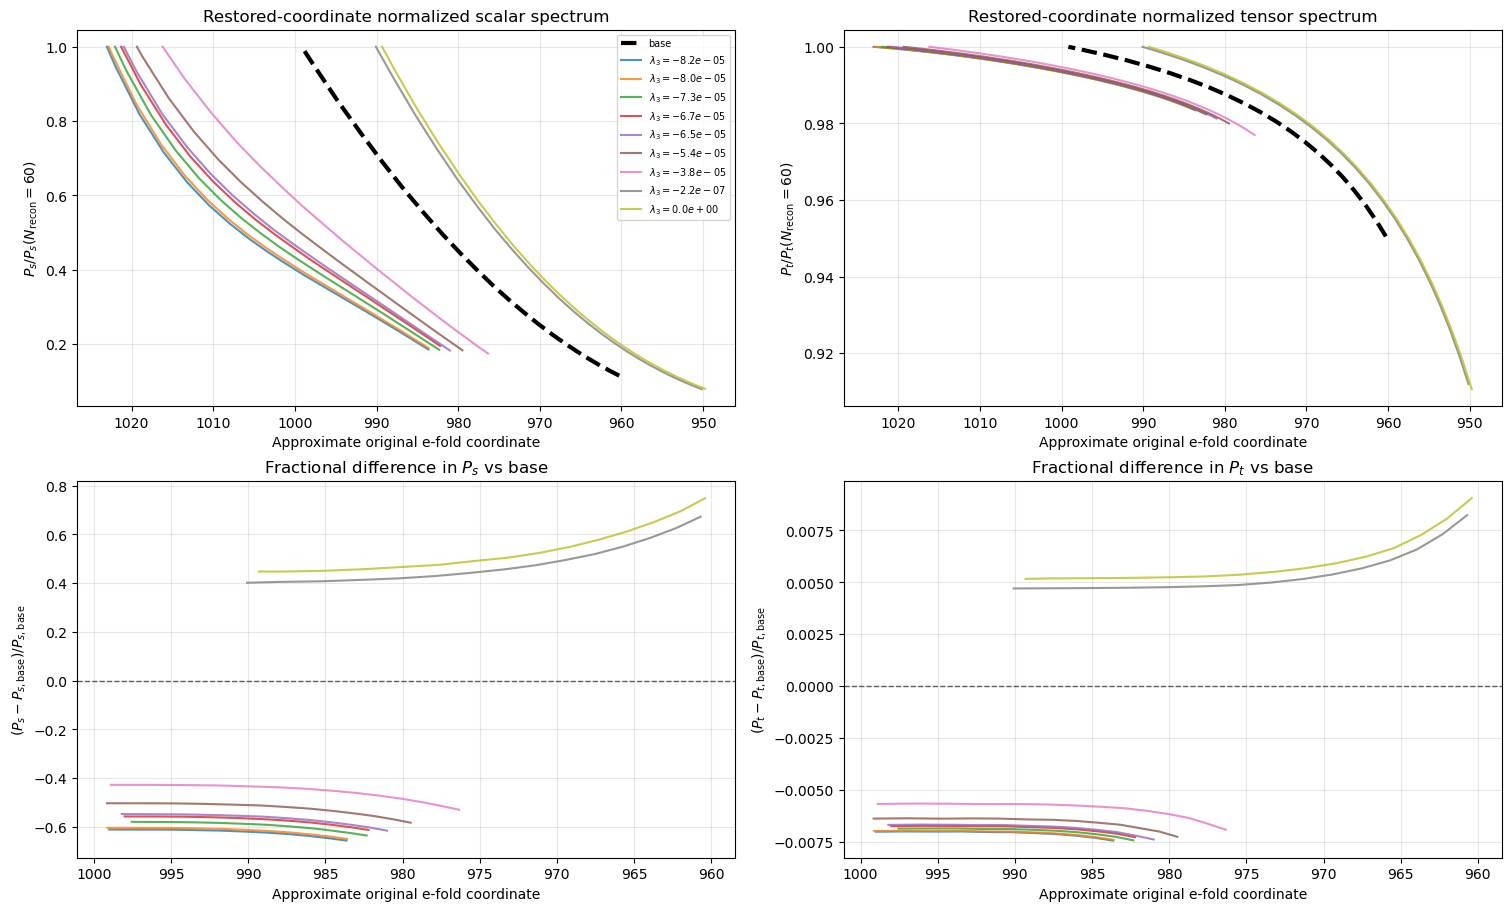

         lam3  N_overlap_min  N_overlap_max  mean_frac_Ps_pct  max_abs_frac_Ps_pct  mean_frac_Pt_pct  max_abs_frac_Pt_pct
-8.181654e-05     983.642153     999.163572        -62.464296            65.593523         -0.709665             0.742445
-7.978910e-05     983.604217     999.163572        -61.749520            64.894196         -0.706450             0.738647
-7.296435e-05     982.329267     999.163572        -59.779139            63.495048         -0.699105             0.741227
-6.705256e-05     982.210931     999.163572        -57.484820            61.222631         -0.685843             0.726040
-6.454758e-05     981.006119     999.163572        -56.924441            61.510833         -0.684288             0.737222
-5.385109e-05     979.477830     999.163572        -52.783925            58.244562         -0.657045             0.724210
-3.787876e-05     976.334973     999.163572        -45.966378            52.935399         -0.595229             0.690097
-2.163669e-07     960.26

In [91]:
restored_spec_err_df = plot_lambda3_spectra_vs_restored_N_with_frac_error(
    merged=merged,
    NEQS=6,
    base_path_root=base_path_root,
    base_lam3=-4.6097100000e-6,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
)

print(restored_spec_err_df.to_string(index=False))

# Models lie near a universal trajectory, but λ₃ moves you along it AND slightly deforms it

In [94]:
def plot_spectra_derivatives_bspline_2x2(
    NEQS,
    lamX_values,
    base_path_root,
    ns_min=0.963,
    ns_max=0.969,
    k_min_plot=None,
    k_max_plot=None,
    smoothing=0.0,
    cmap_name="plasma",
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.interpolate import UnivariateSpline
    from matplotlib import cm, colors as mcolors

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        return k_s, Ps, k_t, Pt

    def prepare_log_spline(k, P, smoothing=0.0):
        k = np.asarray(k)
        P = np.asarray(P)

        mask = (k > 0) & (P > 0) & np.isfinite(k) & np.isfinite(P)
        k = k[mask]
        P = P[mask]

        order = np.argsort(k)
        k = k[order]
        P = P[order]

        x = np.log(k)
        y = np.log(P)

        # Remove duplicate x values if any
        x_unique, idx = np.unique(x, return_index=True)
        y_unique = y[idx]

        spl = UnivariateSpline(x_unique, y_unique, s=smoothing, k=3)

        y1 = spl.derivative(1)(x_unique)
        y2 = spl.derivative(2)(x_unique)

        return np.exp(x_unique), y1, y2

    lam_vals = sanitize_lam_values(lamX_values)

    kept = []

    for lam in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lam)

            if not (ns_min <= ns <= ns_max):
                continue

            k_s, Ps, k_t, Pt = load_specs(lam)

            k_s_use, d1Ps, d2Ps = prepare_log_spline(k_s, Ps, smoothing=smoothing)
            k_t_use, d1Pt, d2Pt = prepare_log_spline(k_t, Pt, smoothing=smoothing)

            kept.append({
                "lam": lam,
                "ns": ns,
                "k_s": k_s_use,
                "d1Ps": d1Ps,
                "d2Ps": d2Ps,
                "k_t": k_t_use,
                "d1Pt": d1Pt,
                "d2Pt": d2Pt,
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lam:.5e}")
        except Exception as e:
            print(f"Skipping {scan_name}={lam:.5e}: {e}")

    print(f"Models kept in ns window [{ns_min}, {ns_max}]: {len(kept)}")

    if len(kept) == 0:
        return None

    lam_kept = np.array([m["lam"] for m in kept])
    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    ax_d1Ps, ax_d1Pt = axes[0]
    ax_d2Ps, ax_d2Pt = axes[1]

    for m in kept:
        color = cmap(norm(m["lam"]))

        mask_s = np.ones_like(m["k_s"], dtype=bool)
        mask_t = np.ones_like(m["k_t"], dtype=bool)

        if k_min_plot is not None:
            mask_s &= m["k_s"] >= k_min_plot
            mask_t &= m["k_t"] >= k_min_plot

        if k_max_plot is not None:
            mask_s &= m["k_s"] <= k_max_plot
            mask_t &= m["k_t"] <= k_max_plot

        ax_d1Ps.semilogx(m["k_s"][mask_s], m["d1Ps"][mask_s], color=color, lw=1.5, alpha=0.85)
        ax_d1Pt.semilogx(m["k_t"][mask_t], m["d1Pt"][mask_t], color=color, lw=1.5, alpha=0.85)

        ax_d2Ps.semilogx(m["k_s"][mask_s], m["d2Ps"][mask_s], color=color, lw=1.5, alpha=0.85)
        ax_d2Pt.semilogx(m["k_t"][mask_t], m["d2Pt"][mask_t], color=color, lw=1.5, alpha=0.85)

    ax_d1Ps.set_title(r"Scalar first derivative: $d\ln P_s / d\ln k$")
    ax_d1Pt.set_title(r"Tensor first derivative: $d\ln P_t / d\ln k$")
    ax_d2Ps.set_title(r"Scalar second derivative: $d^2\ln P_s / d(\ln k)^2$")
    ax_d2Pt.set_title(r"Tensor second derivative: $d^2\ln P_t / d(\ln k)^2$")

    for ax in axes.ravel():
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.5)
        ax.set_xlabel(r"$k$")
        ax.grid(True, alpha=0.25)

    ax_d1Ps.set_ylabel(r"$d\ln P_s / d\ln k$")
    ax_d1Pt.set_ylabel(r"$d\ln P_t / d\ln k$")
    ax_d2Ps.set_ylabel(r"$d^2\ln P_s / d(\ln k)^2$")
    ax_d2Pt.set_ylabel(r"$d^2\ln P_t / d(\ln k)^2$")

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    fig.suptitle(
        rf"B-spline derivatives of spectra for ${ns_min}\leq n_s\leq {ns_max}$",
        fontsize=16,
    )

    plt.show()

    return kept

Models kept in ns window [0.94, 0.98]: 10


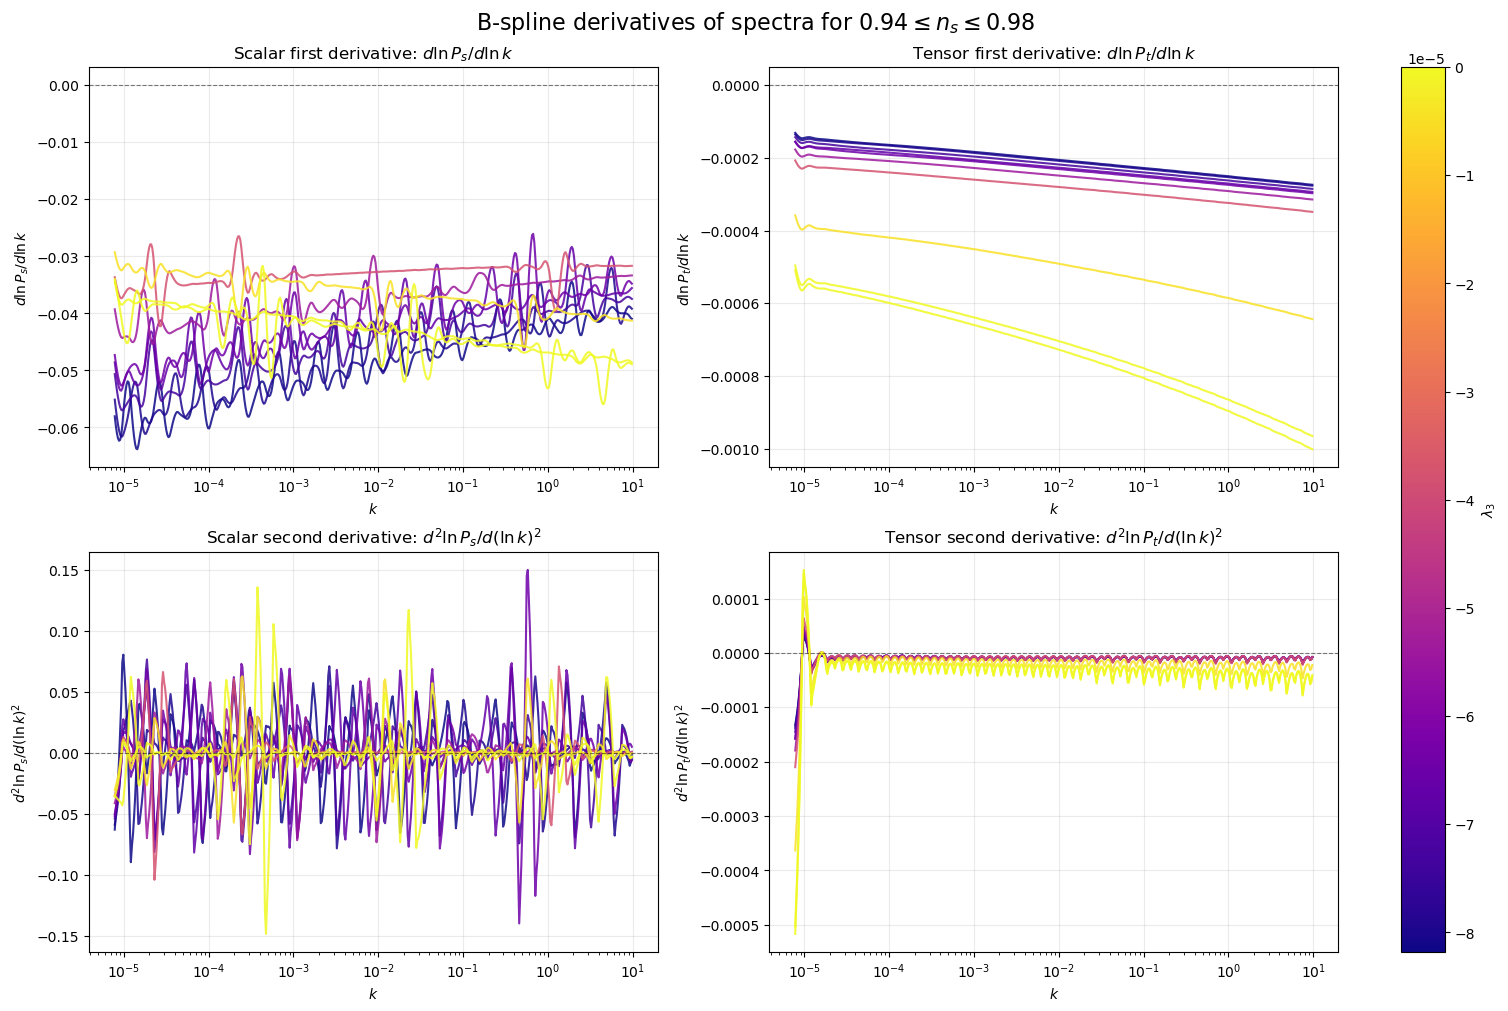

In [96]:
deriv_models = plot_spectra_derivatives_bspline_2x2(
    NEQS=6,
    lamX_values=lam3_values,
    base_path_root=base_path_root,
    ns_min=0.94,
    ns_max=0.98,
    k_min_plot=None,
    k_max_plot=10.0,
    smoothing=0.0,
)

In [92]:
def plot_filtered_spectra_by_ns_vs_N(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.963,
    ns_max=0.969,
    ns_target=0.967,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    import os
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib import cm, colors as mcolors

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_path(value):
        val_str = f"{value:.10e}"
        file_path = os.path.join(
            folder_for(value),
            f"path_neqs{NEQS}_{scan_name}_{val_str}.dat"
        )
        return pd.read_csv(file_path, sep=r"\s+", header=None).values

    def load_specs(value):
        folder = folder_for(value)
        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))
        return s[:, 0], np.abs(s[:, 1]), t[:, 0], np.abs(t[:, 1])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)
        y_ref = np.interp(x_ref, x, y)
        return x, y / y_ref

    def build_spectra_vs_N(value):
        path = load_path(value)
        k_s, Ps_k, k_t, Pt_k = load_specs(value)

        N_path = path[:, NEQS]
        H_path = path[:, 1]

        N_path, H_path = prepare_increasing(N_path, H_path)

        H_ref = np.interp(N_ref, N_path, H_path)
        k_ref_hmpc = 1.73e-61 / 5.41e-58

        k_cross = k_ref_hmpc * np.exp(N_ref - N_path) * H_path / H_ref

        mask_s = (k_cross >= np.min(k_s)) & (k_cross <= np.max(k_s))
        mask_t = (k_cross >= np.min(k_t)) & (k_cross <= np.max(k_t))

        N_s = N_path[mask_s]
        N_t = N_path[mask_t]

        Ps_N = np.interp(k_cross[mask_s], k_s, Ps_k)
        Pt_N = np.interp(k_cross[mask_t], k_t, Pt_k)

        N_s, Ps_norm = normalize_at_ref(N_s, Ps_N, N_ref)
        N_t, Pt_norm = normalize_at_ref(N_t, Pt_N, N_ref)

        mask_Ns = (N_s >= N_min) & (N_s <= N_max)
        mask_Nt = (N_t >= N_min) & (N_t <= N_max)

        return N_s[mask_Ns], Ps_norm[mask_Ns], N_t[mask_Nt], Pt_norm[mask_Nt]

    def frac_on_base_grid(N_base, Y_base, N_cmp, Y_cmp):
        N_base, Y_base = prepare_increasing(N_base, Y_base)
        N_cmp, Y_cmp = prepare_increasing(N_cmp, Y_cmp)

        xmin = max(np.min(N_base), np.min(N_cmp))
        xmax = min(np.max(N_base), np.max(N_cmp))

        mask = (N_base >= xmin) & (N_base <= xmax)
        N_use = N_base[mask]
        Y_base_use = Y_base[mask]
        Y_cmp_interp = np.interp(N_use, N_cmp, Y_cmp)

        frac = (Y_cmp_interp - Y_base_use) / Y_base_use
        return N_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)
    N_s_base, Ps_base_norm, N_t_base, Pt_base_norm = build_spectra_vs_N(baseX)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)
            N_s, Ps_norm, N_t, Pt_norm = build_spectra_vs_N(lamX)

            N_ps_err, frac_ps = frac_on_base_grid(
                N_s_base, Ps_base_norm, N_s, Ps_norm
            )

            N_pt_err, frac_pt = frac_on_base_grid(
                N_t_base, Pt_base_norm, N_t, Pt_norm
            )

            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "N_s": N_s,
                    "Ps_norm": Ps_norm,
                    "N_t": N_t,
                    "Pt_norm": Pt_norm,
                    "N_ps_err": N_ps_err,
                    "frac_ps": frac_ps,
                    "N_pt_err": N_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX", "ns", "delta_ns_from_base",
                "mean_dPs_pct", "max_dPs_pct",
                "mean_dPt_pct", "max_dPt_pct"
            ]].to_string(index=False)
        )

    fig, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            ax_ps.plot(
                m["N_s"], m["Ps_norm"],
                color=color, lw=1.8, alpha=0.85
            )

            ax_pt.plot(
                m["N_t"], m["Pt_norm"],
                color=color, lw=1.8, alpha=0.85
            )

            ax_ps_err.plot(
                m["N_ps_err"], 100.0 * m["frac_ps"],
                color=color, lw=1.5, alpha=0.85
            )

            ax_pt_err.plot(
                m["N_pt_err"], 100.0 * m["frac_pt"],
                color=color, lw=1.5, alpha=0.85
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    ax_ps.plot(
        N_s_base, Ps_base_norm,
        color="black", lw=3, ls="--",
        label=rf"base $n_s={ns_base:.4f}$"
    )

    ax_pt.plot(
        N_t_base, Pt_base_norm,
        color="black", lw=3, ls="--",
        label=rf"base $n_s={ns_base:.4f}$"
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(0.0, color="black", ls="--", lw=0.8, alpha=0.6)

    ax_ps.axvline(N_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(N_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(rf"Filtered normalized scalar spectra: $P_s(N)/P_s({N_ref})$")
    ax_pt.set_title(rf"Filtered normalized tensor spectra: $P_t(N)/P_t({N_ref})$")
    ax_ps_err.set_title(r"Filtered scalar fractional error vs base")
    ax_pt_err.set_title(r"Filtered tensor fractional error vs base")

    ax_ps.set_ylabel(rf"$P_s(N)/P_s({N_ref})$")
    ax_pt.set_ylabel(rf"$P_t(N)/P_t({N_ref})$")
    ax_ps_err.set_ylabel(r"% difference in $P_s(N)$")
    ax_pt_err.set_ylabel(r"% difference in $P_t(N)$")

    for ax in axes.ravel():
        ax.set_xlabel(r"$N_{\rm cross}$")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=8)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$), spectra vs $N$",
        fontsize=16,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_{ns_min}_{ns_max}_spectra_vs_N.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df


=== All models summary ===
Total loaded: 10
Base ns: 0.965678
Models in ns window [0.963, 0.969]: 2

=== Filtered models by ns cut ===
     lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-0.000005 0.965678            0.000000      0.000000     0.000000      0.000000     0.000000
-0.000038 0.966154            0.000476     28.649184    64.781248      1.062592     2.923463


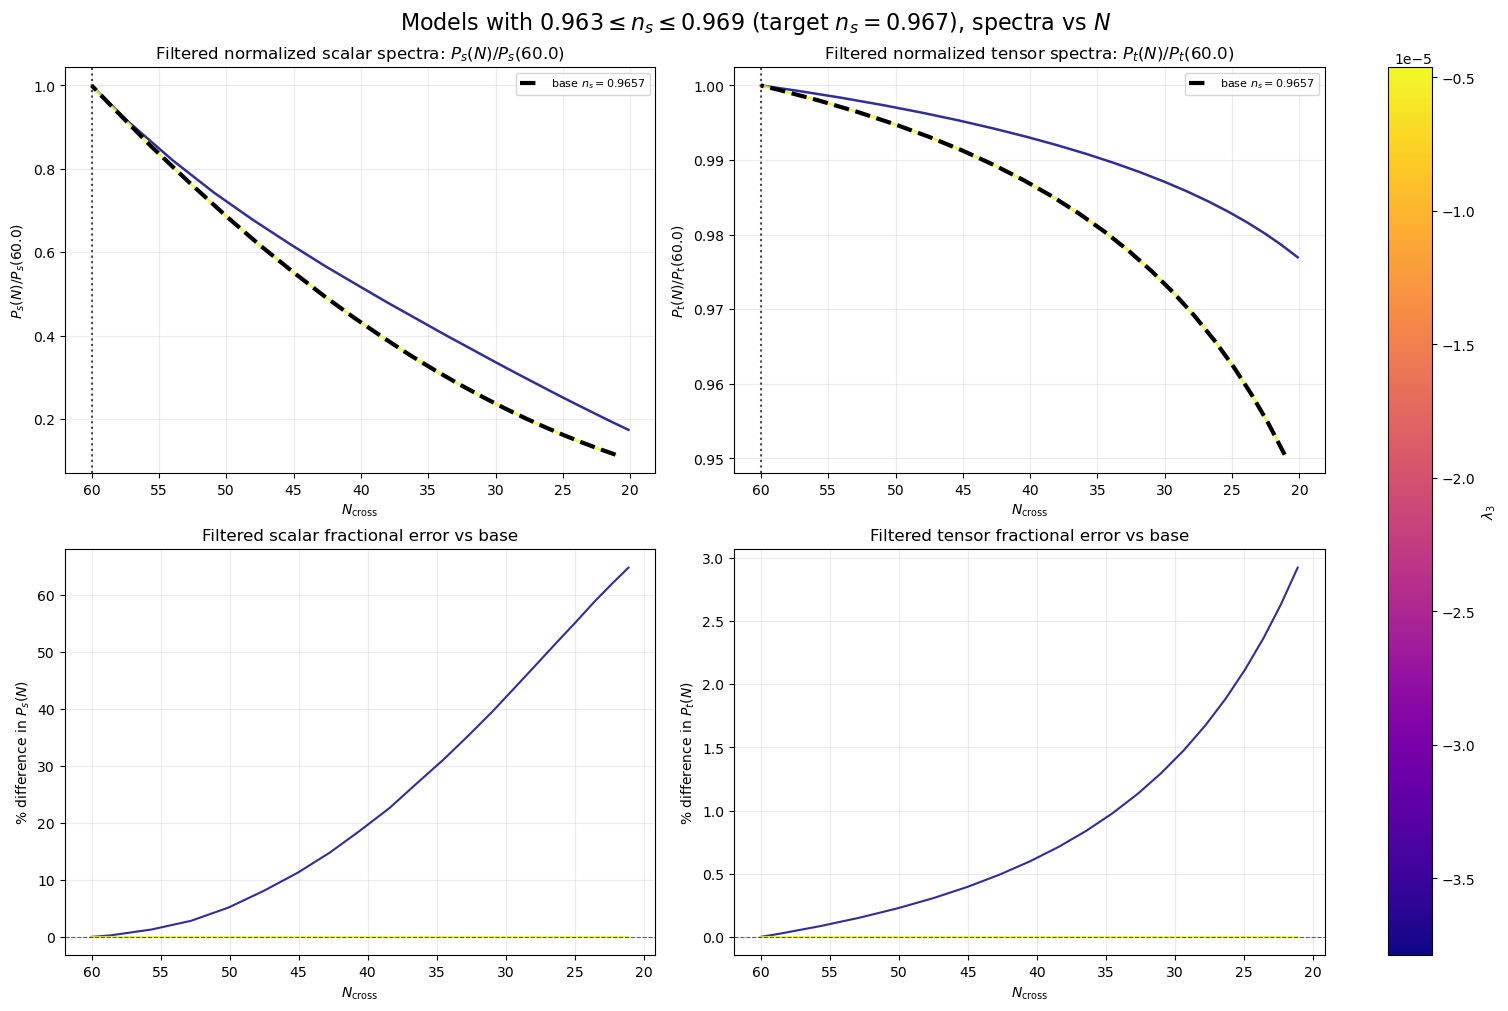

In [93]:
stats_N_df, kept_N_df = plot_filtered_spectra_by_ns_vs_N(
    NEQS=6,
    lamX_values=lam3_values,
    baseX=-4.6097100000e-6,
    base_path_root=base_path_root,
    ns_min=0.963,
    ns_max=0.969,
    ns_target=0.967,
    N_ref=60.0,
    N_min=20.0,
    N_max=60.0,
    save_name="neqs6_lam3_filtered_ns_spectra_vs_N.png",
)